![Agencia de viajes](./img/img.png)




## **CLA Flight Intelligence**

CLA Flight Intelligence — Travel Agency India es una agencia especializada en vuelos nacionales dentro de India, un mercado donde los precios fluctúan de manera constante debido a factores como la aerolínea, la duración del trayecto, el número de escalas y, especialmente, la antelación con la que se realiza la reserva. Para ofrecer a nuestros clientes las mejores opciones posibles, necesitamos comprender cómo evolucionan los precios y anticipar cuándo es más conveniente comprar un billete.

El objetivo del proyecto es desarrollar un modelo de Machine Learning capaz de predecir el precio esperado de un vuelo nacional en India a partir de sus características principales. Esta predicción permite a CLA Flight Intelligence recomendar a los clientes si es un buen momento para reservar, identificar vuelos con precios inusualmente altos o bajos y optimizar las estrategias comerciales y de marketing de la agencia.

Aunque el dataset cubre únicamente vuelos entre el 11 de febrero y el 31 de marzo, incluye la variable más determinante en el pricing aéreo: la antelación de compra (days_left). Esto permite modelar patrones reales de comportamiento del precio en el corto plazo, suficientes para mejorar la toma de decisiones de la agencia y ofrecer recomendaciones basadas en datos.

El modelo resultante ayuda a CLA Flight Intelligence — Travel Agency India a:

- Recomendar el mejor momento para reservar un vuelo dentro de India,
- Detectar oportunidades de compra cuando un precio está por debajo de lo habitual,
- Priorizar rutas y aerolíneas con mejor relación calidad‑precio,
- Mejorar la experiencia del cliente mediante información personalizada y fundamentada en datos.

#### **Paso 0: Importar librerías**

In [1]:
import matplotlib.pyplot as plt
import joblib
import numpy as np
import optuna
import os
import pandas as pd
import re
import seaborn as sns
import sys

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, cross_val_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

from scipy import stats

sys.path.append(os.path.abspath("./src/utils"))
import bootcampviztools as bt

pd.options.mode.copy_on_write = True

In [2]:
# ============================================
# LIBRERÍAS NECESARIAS PARA TODO EL PIPELINE
# ============================================

# --- Python estándar ---
import re
import numpy as np
import pandas as pd

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Scikit-Learn: Transformadores y Preprocesado ---
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline

# --- Scikit-Learn: Modelos ---
from sklearn.ensemble import RandomForestRegressor

# --- Scikit-Learn: Métricas ---
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

# --- Scikit-Learn: Validación ---
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    KFold
)

# --- XGBoost ---
from xgboost import XGBRegressor

# --- LightGBM ---
from lightgbm import LGBMRegressor

# --- CatBoost (si lo usas) ---
from catboost import CatBoostRegressor

# --- Otros (si los usas en tu notebook) ---
from scipy import stats
import bootcampviztools as bt


#### **Paso 1: Cargar los datos**

In [3]:
df_economy= pd.read_csv("../data/economy.csv")
df_eco=df_economy.copy()
df_business = pd.read_csv("../data/business.csv")
df_bus=df_business.copy()

In [4]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.4+ MB


In [5]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB


Añado la columna class para separa entre Economy y Business:

In [6]:
df_eco["class"] = "economy"
df_bus["class"] = "business"

Transformer 1: Convertir duración

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin
import re
import numpy as np

class DurationTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        def convert(x):
            h = re.search(r'(\d+)h', x)
            m = re.search(r'(\d+)m', x)
            hours = int(h.group(1)) if h else 0
            minutes = int(m.group(1)) if m else 0
            return hours + minutes/60
        X["duration(h)"] = X["time_taken"].apply(convert)
        return X


Transformer 2: Categorizar horas

In [8]:
class TimeCategoryTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["dep_time"] = pd.to_datetime(X["dep_time"], format="%H:%M")
        X["arr_time"] = pd.to_datetime(X["arr_time"], format="%H:%M")

        def categorize(h):
            if 0 <= h < 4: return "Late Night"
            if 4 <= h < 8: return "Early Morning"
            if 8 <= h < 12: return "Morning"
            if 12 <= h < 16: return "Afternoon"
            if 16 <= h < 20: return "Evening"
            return "Night"

        X["dep_time_cat"] = X["dep_time"].dt.hour.apply(categorize)
        X["arr_time_cat"] = X["arr_time"].dt.hour.apply(categorize)
        return X


Transformer 3: Limpiar stops

In [9]:
class StopCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        def clean(x):
            x = x.lower().strip()
            if "non" in x: return "non-stop"
            m = re.search(r'(\d+)', x)
            if m: return f"{m.group(1)}-stop"
            return "unknown"
        X["stop"] = X["stop"].apply(clean)
        X["stop_num"] = X["stop"].replace({
            "non-stop": 0,
            "1-stop": 1,
            "2-stop": 2
        }).astype(int)
        return X


Transformer 4: Calcular days_left

In [10]:
class DaysLeftTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, scraping_date="10-02-2022"):
        self.scraping_date = pd.to_datetime(scraping_date, format="%d-%m-%Y")
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        X["date"] = pd.to_datetime(X["date"], format="%d-%m-%Y", errors="coerce")
        X["days_left"] = (X["date"] - self.scraping_date).dt.days
        return X


Transformer 5: Eliminar columnas irrelevantes

In [11]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])


Transformer 6: Convertir price a float

In [12]:
class PriceToFloat(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()

        # convertir a float
        X["price"] = (
            X["price"]
            .astype(str)
            .str.replace(",", "")
            .astype(float)
        )

        # renombrar con unidades
        X = X.rename(columns={"price": "price (INR)"})

        return X


Tranformer 7: Agrupar las aerolineas

In [13]:
class AirlineGrouper(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.rare_airlines = ["SpiceJet", "StarAir", "Trujet", "AirAsia"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["airline"] = X["airline"].replace(self.rare_airlines, "Other")
        return X


Tranformer 8: Eliminar los duplicados

In [14]:
class DropDuplicates(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.drop_duplicates().reset_index(drop=True)


Pipeline ETL completo dentro de sklearn

In [15]:
cols_to_drop = [
    "dep_time", "arr_time", "date", "time_taken",
    "ch_code", "num_code", "dep_hour", "arr_hour",
    "flight", "stop"
]

etl_pipeline = Pipeline([
    ("price_float", PriceToFloat()),
    ("duration", DurationTransformer()),
    ("time_cat", TimeCategoryTransformer()),
    ("stop_clean", StopCleaner()),
    ("days_left", DaysLeftTransformer()),
    ("drop_cols", ColumnDropper(cols_to_drop)),
    ("airline_group", AirlineGrouper()),
    ("drop_dupes", DropDuplicates()),
])



In [16]:
df_eco_clean = etl_pipeline.fit_transform(df_eco)
df_bus_clean = etl_pipeline.fit_transform(df_bus);

C:\Users\lufue\AppData\Local\Temp\ipykernel_28872\2693101301.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["stop_num"] = X["stop"].replace({
C:\Users\lufue\AppData\Local\Temp\ipykernel_28872\2693101301.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["stop_num"] = X["stop"].replace({


In [17]:
df_eco_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205016 entries, 0 to 205015
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   airline       205016 non-null  object 
 1   from          205016 non-null  object 
 2   to            205016 non-null  object 
 3   price (INR)   205016 non-null  float64
 4   class         205016 non-null  object 
 5   duration(h)   205016 non-null  float64
 6   dep_time_cat  205016 non-null  object 
 7   arr_time_cat  205016 non-null  object 
 8   stop_num      205016 non-null  int64  
 9   days_left     205016 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 15.6+ MB


In [18]:
df_bus_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93176 entries, 0 to 93175
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   airline       93176 non-null  object 
 1   from          93176 non-null  object 
 2   to            93176 non-null  object 
 3   price (INR)   93176 non-null  float64
 4   class         93176 non-null  object 
 5   duration(h)   93176 non-null  float64
 6   dep_time_cat  93176 non-null  object 
 7   arr_time_cat  93176 non-null  object 
 8   stop_num      93176 non-null  int64  
 9   days_left     93176 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 7.1+ MB


#### **Paso 2: Mini-EDA**

**Análisis univariante**

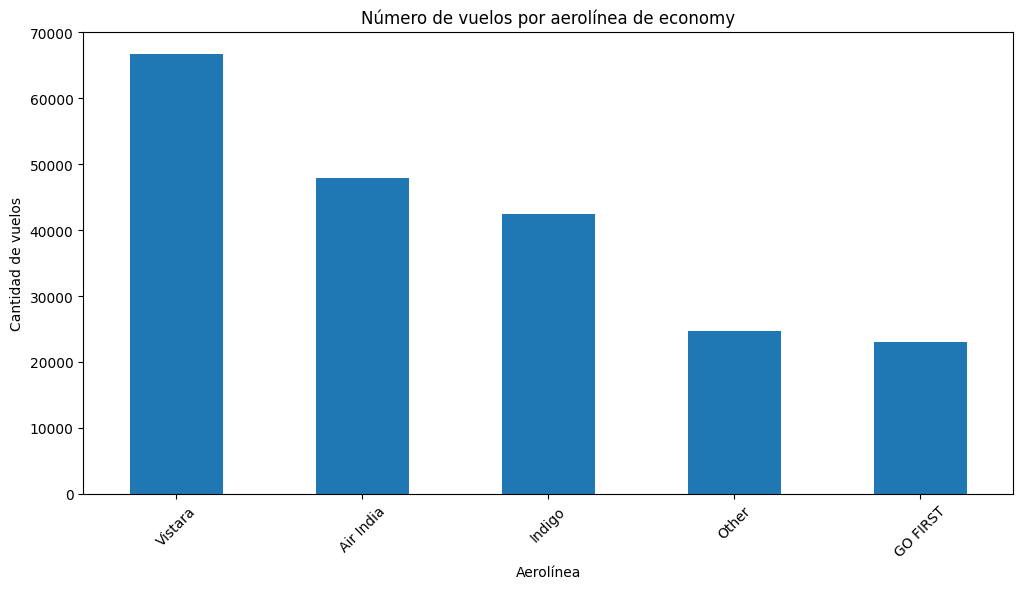

In [55]:
plt.figure(figsize=(12,6))
df_eco_clean['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea de economy")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


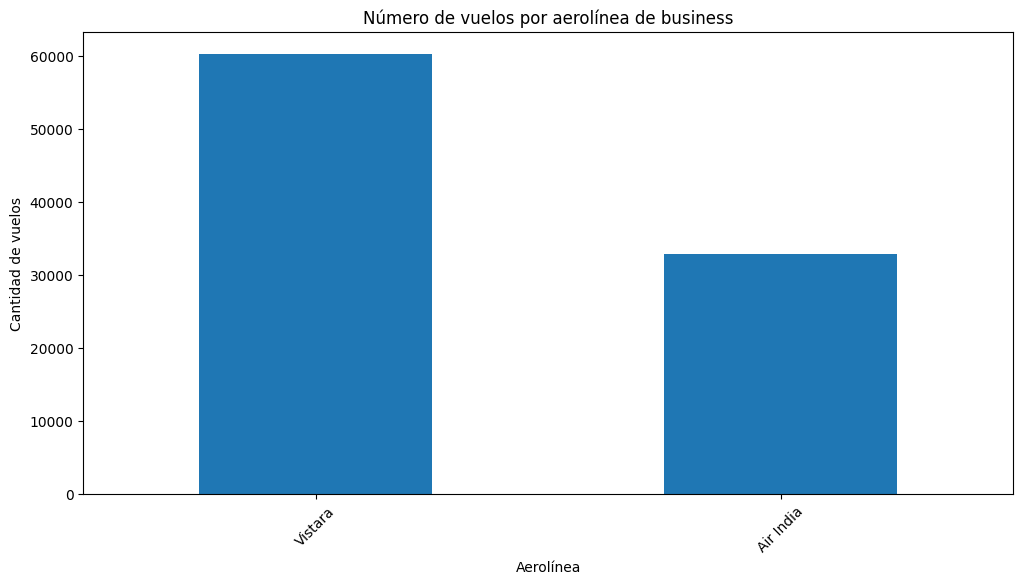

In [56]:
plt.figure(figsize=(12,6))
df_bus_clean['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea de business")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


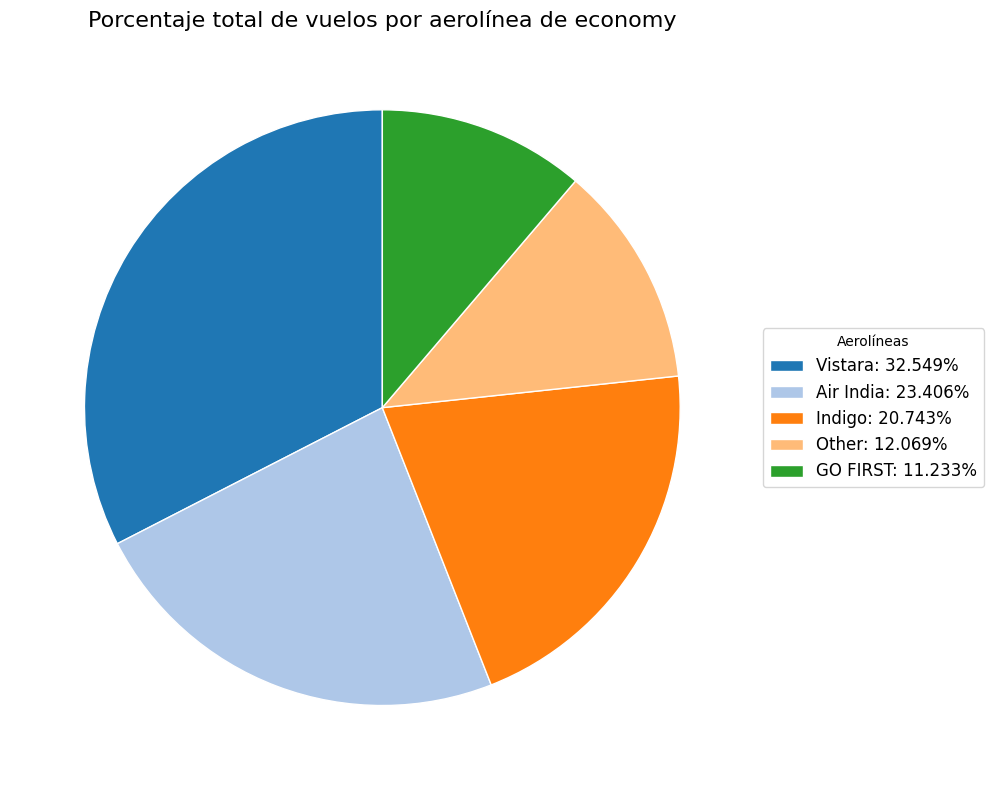

In [57]:
# Conteo y porcentaje
counts = df_eco_clean["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea de economy", fontsize=16)
plt.tight_layout()
plt.show()


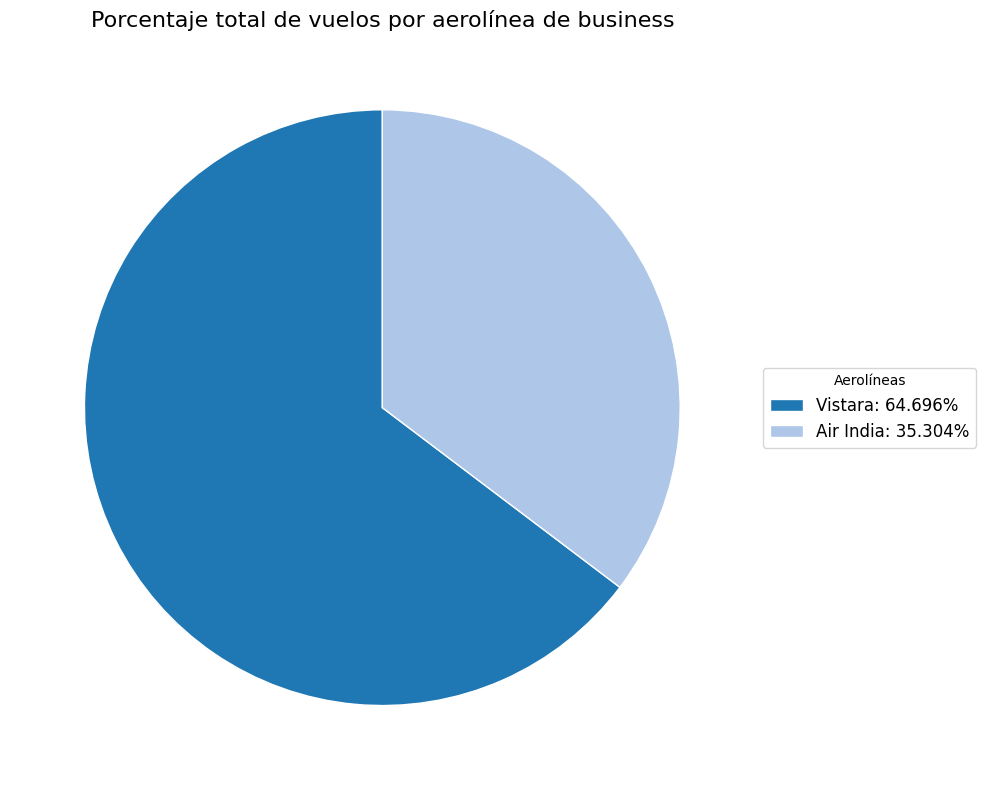

In [58]:
# Conteo y porcentaje
counts = df_bus_clean["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea de business", fontsize=16)
plt.tight_layout()
plt.show()


Para ver relaciones lineales utilizamos la matriz de correlacion

In [19]:
class CorrelationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df_num = X[self.columns]
        corr_matrix = df_num.corr()
        return corr_matrix


In [20]:
num_cols = ['price (INR)', 'duration(h)', 'stop_num', 'days_left']

corr_pipeline = Pipeline([
    ('corr', CorrelationTransformer(columns=num_cols))
])

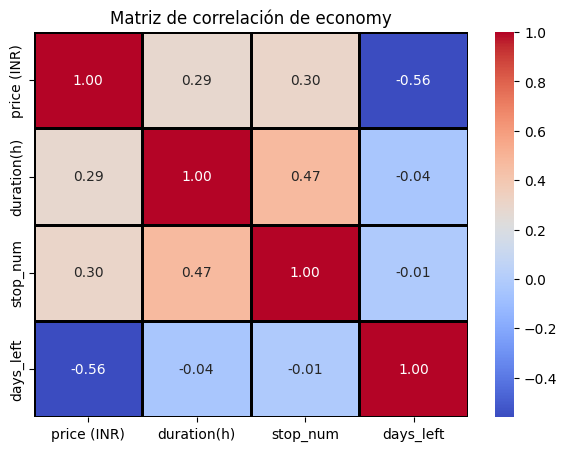

In [21]:
# 4. Ejecutar pipeline
corr_matrix = corr_pipeline.fit_transform(df_eco_clean)

# 5. Heatmap con casillas independientes
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1,      # ← bordes entre casillas
    linecolor='black'  # ← color de los bordes
)
plt.title("Matriz de correlación de economy")
plt.show()


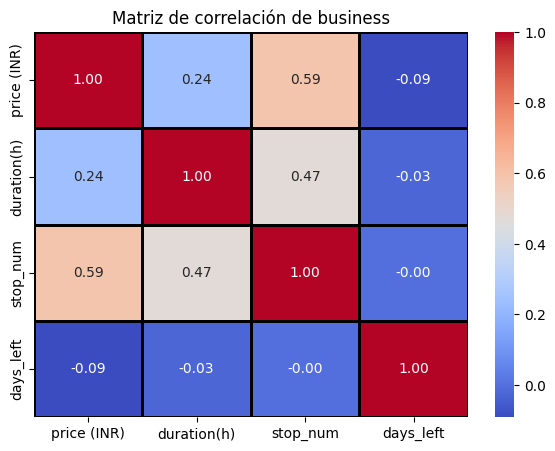

In [22]:
# 4. Ejecutar pipeline
corr_matrix = corr_pipeline.fit_transform(df_bus_clean)

# 5. Heatmap con casillas independientes
plt.figure(figsize=(7,5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=1,      # ← bordes entre casillas
    linecolor='black'  # ← color de los bordes
)
plt.title("Matriz de correlación de business")
plt.show()

**Análisis del target**

In [22]:
class TargetExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, target):
        self.target = target
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[[self.target]]


In [23]:
target = 'price (INR)'

target_pipeline = Pipeline([
    ('extract_target', TargetExtractor(target=target))
])

target_df = target_pipeline.fit_transform(df_eco_clean)


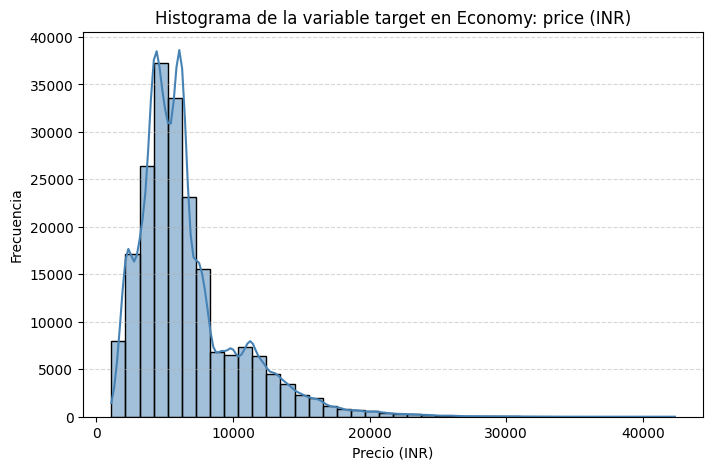

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=target_df,
    x=target,
    bins=40,
    kde=True,
    color='steelblue',
    edgecolor='black',   # ← bordes para que se vean las casillas
    linewidth=1
)

plt.title("Histograma de la variable target en Economy: price (INR)")
plt.xlabel("Precio (INR)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [24]:
target_df_bus = target_pipeline.fit_transform(df_bus_clean)

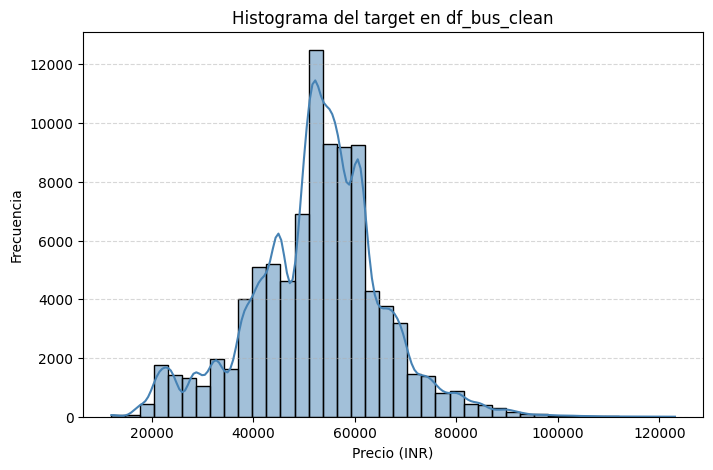

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=target_df_bus,
    x=target,
    bins=40,
    kde=True,
    color='steelblue',
    edgecolor='black',
    linewidth=1
)

plt.title("Histograma del target en df_bus_clean")
plt.xlabel("Precio (INR)")
plt.ylabel("Frecuencia")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


In [28]:
# plt.figure(figsize=(10, 6))
# sns.histplot(df_final[df_final["class"] == "economy"][target_reg], bins=50, kde=True, label = "Economy")
# sns.histplot(df_final[df_final["class"] == "business"][target_reg], bins=50, kde=True, label = "Business")
# plt.title("Distribución de Price por clase")
# plt.xlabel("Price(Rupias)")
# plt.legend()
# plt.show()

**Vamos a verificar outlier**

In [29]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class OutlierDetectorIQR(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.num_cols = None
        self.bounds = {}
    
    def fit(self, X, y=None):
        self.num_cols = X.select_dtypes(include=['int64', 'float64']).columns
        
        for col in self.num_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 5 * IQR
            self.bounds[col] = (lower, upper)
        
        return self
    
    def transform(self, X):
        X_out = X.copy()
        X_out["is_outlier"] = False
        
        for col in self.num_cols:
            lower, upper = self.bounds[col]
            mask = (X[col] < lower) | (X[col] > upper)
            X_out["is_outlier"] = X_out["is_outlier"] | mask
        
        return X_out



In [30]:
from sklearn.pipeline import Pipeline

outlier_pipeline = Pipeline([
    ('outliers', OutlierDetectorIQR())
])


In [31]:
df_eco_out = outlier_pipeline.fit_transform(df_eco_clean)
df_eco_out.head()


,airline,from,to,price (INR),class,duration(h),dep_time_cat,arr_time_cat,stop_num,days_left,is_outlier
0,Other,Delhi,Mumbai,5953.0,economy,2.166667,Evening,Night,0,1,True
1,Other,Delhi,Mumbai,5953.0,economy,2.333333,Early Morning,Morning,0,1,True
2,Other,Delhi,Mumbai,5956.0,economy,2.166667,Early Morning,Early Morning,0,1,True
3,Vistara,Delhi,Mumbai,5955.0,economy,2.250000,Morning,Afternoon,0,1,True
4,Vistara,Delhi,Mumbai,5955.0,economy,2.333333,Morning,Morning,0,1,True


In [32]:
df_eco_out['is_outlier'].value_counts()


is_outlier
False    165939
True      39077
Name: count, dtype: int64

In [33]:
# df_bus_out['is_outlier'].value_counts()

In [34]:
df_bus_out = outlier_pipeline.fit_transform(df_bus_clean)
df_bus_out.head()


,airline,from,to,price (INR),class,duration(h),dep_time_cat,arr_time_cat,stop_num,days_left,is_outlier
0,Air India,Delhi,Mumbai,25612.0,business,2.000000,Evening,Night,0,1,True
1,Air India,Delhi,Mumbai,25612.0,business,2.250000,Evening,Night,0,1,True
2,Air India,Delhi,Mumbai,42220.0,business,24.750000,Night,Night,1,1,False
3,Air India,Delhi,Mumbai,44450.0,business,26.500000,Night,Night,1,1,False
4,Air India,Delhi,Mumbai,46690.0,business,6.666667,Evening,Night,1,1,False


In [35]:
def boxplot_variable(df, col):
    plt.figure(figsize=(8,4))
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f"Boxplot de {col}")
    plt.show()


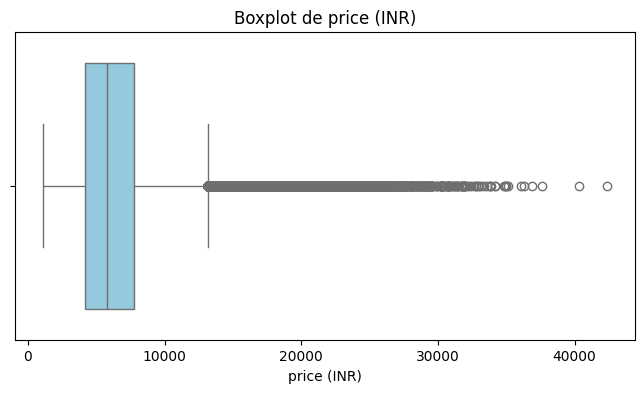

In [36]:
boxplot_variable(df_eco_clean, 'price (INR)')


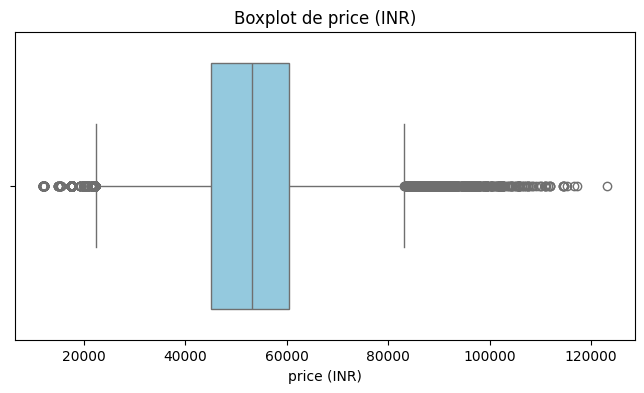

In [37]:
boxplot_variable(df_bus_clean, 'price (INR)')


#### **Paso 3: Split Train y Test**

In [25]:
# # Economy
df_eco_ml = df_eco_clean.copy()
# X_eco = df_eco_ml.drop(columns=["price (INR)"])
# y_eco = df_eco_ml["price (INR)"]

# # Business
df_bus_ml = df_bus_clean.copy()
# X_bus = df_bus_ml.drop(columns=["price (INR)"])
# y_bus = df_bus_ml["price (INR)"]


In [26]:
df_eco_ml["price_bin"] = pd.qcut(df_eco_ml["price (INR)"], q=10, duplicates="drop")
X_eco = df_eco_ml.drop(columns=["price_bin", "price (INR)"])
y_eco = df_eco_ml["price (INR)"]


df_bus_ml["price_bin"] = pd.qcut(df_bus_ml["price (INR)"], q=10, duplicates="drop")
X_bus = df_bus_ml.drop(columns=["price_bin", "price (INR)"])
y_bus = df_bus_ml["price (INR)"]

In [27]:
X_eco_train, X_eco_test, y_eco_train, y_eco_test = train_test_split(
    X_eco, y_eco, test_size=0.2, random_state=42, stratify = df_eco_ml["price_bin"]
)


In [28]:
X_bus_train, X_bus_test, y_bus_train, y_bus_test = train_test_split(
    X_bus, y_bus, test_size=0.2, random_state=42, stratify = df_bus_ml["price_bin"]
)


#### **Paso 4: Selección de features**

In [29]:
features_num_reg = ["duration(h)", "days_left", "stop_num"]
print(features_num_reg)

features_cat_reg = [col for col in df_eco_clean.columns if col not in features_num_reg and col != target]
print(features_cat_reg)

features = features_num_reg + features_cat_reg

['duration(h)', 'days_left', 'stop_num']
['airline', 'from', 'to', 'class', 'dep_time_cat', 'arr_time_cat']


**Categóricas vs target_reg**

Economy

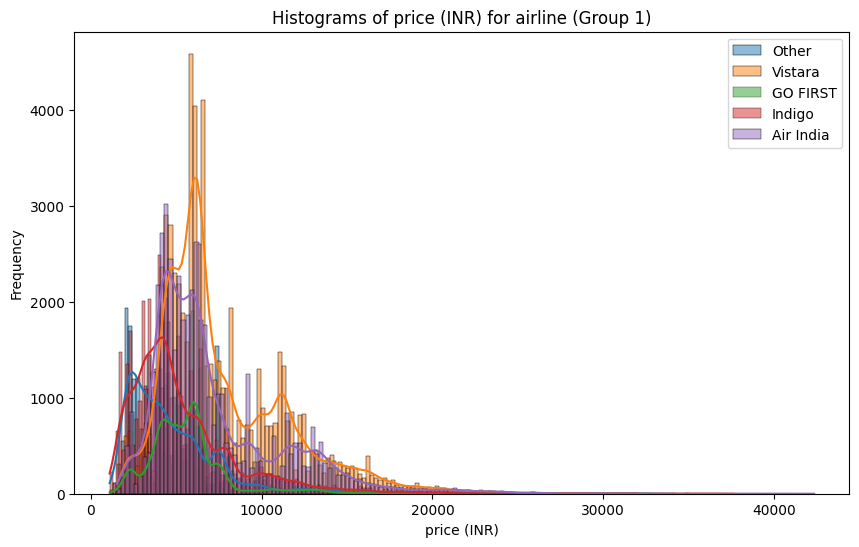

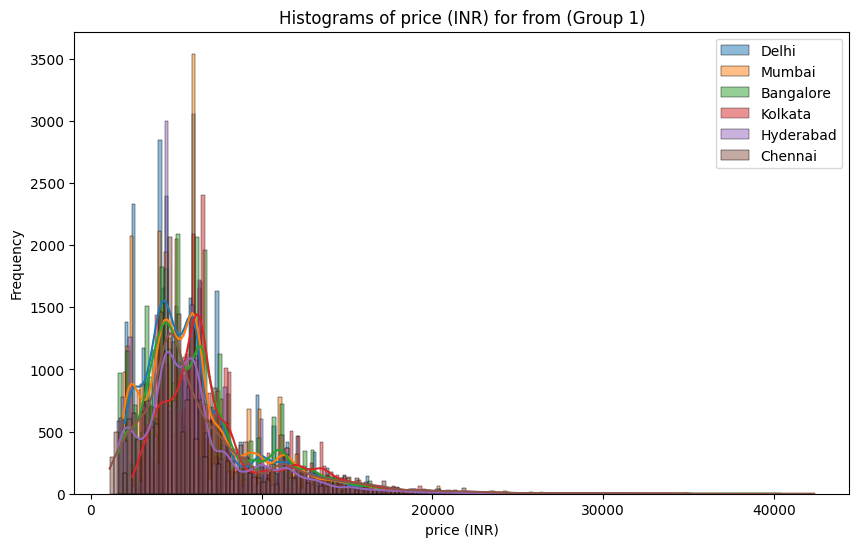

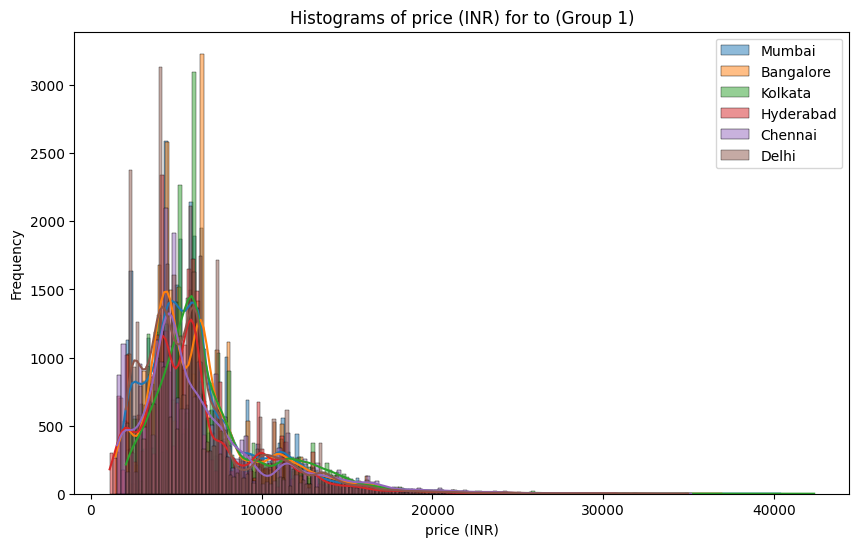

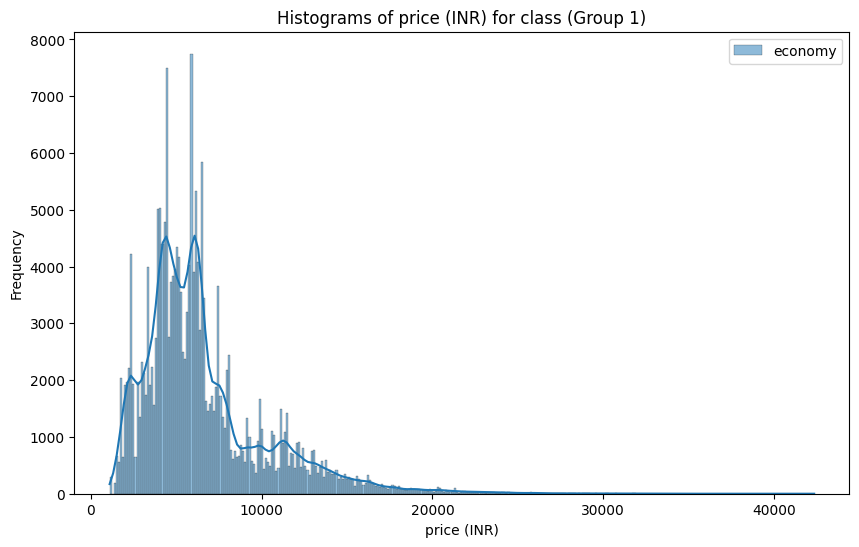

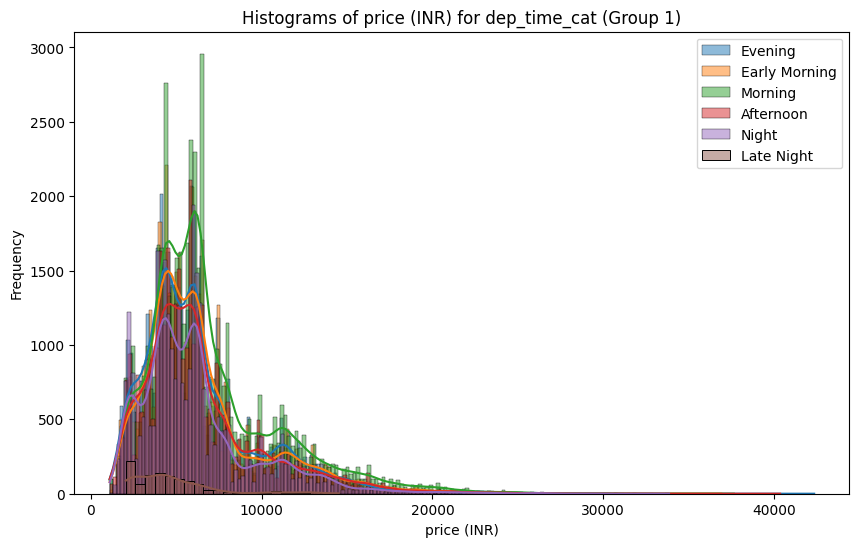

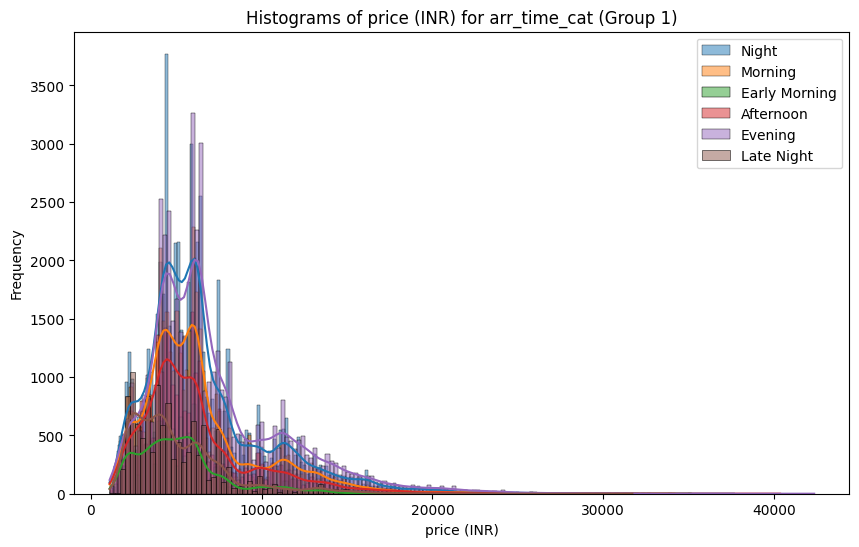

In [61]:
for col_cat in features_cat_reg:
    bt.plot_grouped_histograms(df_eco_clean, cat_col= col_cat, num_col= target, group_size= df_eco_clean[col_cat].nunique())

*Las distribuciones de 'dep_time_cat' y 'arr_time_cat' son las que más superpuestas parecen*.

Lo hago también con el test ANOVA para decidir si me quedo todas o no.

In [62]:
for cat_col in features_cat_reg:
    valores_unicos = df_eco_clean[cat_col].unique()
    target_por_cat_col = [df_eco_clean[df_eco_clean[cat_col] == categoria][target] for categoria in valores_unicos]

    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

airline:
	 Valor de F: 5719.963946082246
	 p-valor: 0.0
from:
	 Valor de F: 486.0591771426423
	 p-valor: 0.0
to:
	 Valor de F: 290.5415193566798
	 p-valor: 6.6887037016055e-311


TypeError: At least two samples are required; got 1.

*Todos los p-valores son muy pequeños (p-valor < 0.01), se puede rechazar la hipótesis nula de que no existe relación entre las variables, así que me quedo con todas.*

#### **Paso 5: Tratamiento de features**

In [30]:
categorias = [["economy", "business"]]
features_cat_reg = [
    "airline", "from", "to", "class",
    "dep_time_cat", "arr_time_cat"
]
cat_cols = [col for col in features_cat_reg if col != "class"]

preprocessor_trees = ColumnTransformer([
    ("procesar_cat_ord", OrdinalEncoder(categories = categorias, handle_unknown = "use_encoded_value", unknown_value = -1), ["class"]),
    ("procesar_cat_OH", OneHotEncoder(handle_unknown = "ignore"), cat_cols)
], remainder = "passthrough")

#### **Paso 6: Baseline**

In [42]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)

#### **Paso 7: Comparación modelos**

Randomforest

In [31]:
rf_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", RandomForestRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", RandomForestRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

XGBoost

In [32]:
xgb_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", XGBRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

xgb_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", XGBRegressor(
        max_depth = 5,
        random_state=42,
        n_jobs=-1
    ))
])

LightGBM

In [33]:
lgbm_eco = Pipeline([
    ("prep", preprocessor_trees),
    ("model", LGBMRegressor(
        max_depth = 5,
        random_state=42
    ))
])

lgbm_bus = Pipeline([
    ("prep", preprocessor_trees),
    ("model", LGBMRegressor(
        max_depth = 5,
        random_state=42
    ))
])

In [34]:
def eval_cv(model, X, y, name):
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2"
    }

    cv = cross_validate(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )

    print(f"\nModel <{name}>")
    print("RMSE_CV:", -cv["test_rmse"].mean())
    print("MAE_CV:", -cv["test_mae"].mean())
    print("R2_CV:", cv["test_r2"].mean())


In [47]:
eval_cv(rf_eco, X_eco, y_eco, "RF Economy")
eval_cv(xgb_eco, X_eco, y_eco, "XGB Economy")
eval_cv(lgbm_eco, X_eco, y_eco, "LGBM Economy")



Model <RF Economy>
RMSE_CV: 2333.1622726951473
MAE_CV: 1555.1331224650592
R2_CV: 0.6102356991290353

Model <XGB Economy>
RMSE_CV: 2195.604729241228
MAE_CV: 1480.4950098056354
R2_CV: 0.6548625692256491

Model <LGBM Economy>
RMSE_CV: 2151.7103312359586
MAE_CV: 1429.2749922381595
R2_CV: 0.6684753300183515


In [52]:
eval_cv(rf_bus, X_bus, y_bus, "RF Business")
eval_cv(xgb_bus, X_bus, y_bus, "XGB Business")
eval_cv(lgbm_bus, X_bus, y_bus, "LGBM Business")


Model <RF Business>
RMSE_CV: 9867.044740345296
MAE_CV: 7497.583597431784
R2_CV: 0.39333677013167645

Model <XGB Business>
RMSE_CV: 9118.824678209283
MAE_CV: 6971.261021185489
R2_CV: 0.48144769348658906

Model <LGBM Business>
RMSE_CV: 9010.673577640026
MAE_CV: 6923.582787141856
R2_CV: 0.495187612699314


In [36]:
df_eco_ml.describe()

,price (INR),duration(h),stop_num,days_left
count,205016.000000,205016.000000,205016.000000,205016.000000
mean,6588.858679,11.612586,0.929698,26.125434
std,3748.841951,7.230707,0.429435,13.523020
min,1105.000000,0.833333,0.000000,1.000000
25%,4181.000000,6.333333,1.000000,15.000000
50%,5778.000000,10.250000,1.000000,26.000000
75%,7767.000000,15.416667,1.000000,38.000000
max,42349.000000,49.833333,2.000000,49.000000


In [ ]:
df_bus_ml.describe()

,price (INR),duration(h),stop_num,days_left
count,93487.000000,93487.000000,93487.000000,93487.000000
mean,52540.081124,13.704224,0.924920,25.741857
std,12969.314606,6.852479,0.304324,13.626538
min,12000.000000,1.000000,0.000000,1.000000
25%,45185.000000,8.833333,1.000000,14.000000
50%,53164.000000,13.083333,1.000000,26.000000
75%,60396.000000,17.833333,1.000000,38.000000
max,123071.000000,47.750000,2.000000,49.000000


In [35]:
def eval_test(model, X_test, y_test, name):
    preds = model.predict(X_test)

    rmse = root_mean_squared_error(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"\nTest results <{name}>")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)


In [50]:
rf_eco.fit(X_eco_train, y_eco_train)
xgb_eco.fit(X_eco_train, y_eco_train)
lgbm_eco.fit(X_eco_train, y_eco_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 164012, number of used features: 32
[LightGBM] [Info] Start training from score 6589.116199
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('procesar_cat_ord', ...), ('procesar_cat_OH', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [53]:
rf_bus.fit(X_bus_train, y_bus_train)
xgb_bus.fit(X_bus_train, y_bus_train)
lgbm_bus.fit(X_bus_train, y_bus_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000805 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 360
[LightGBM] [Info] Number of data points in the train set: 74540, number of used features: 29
[LightGBM] [Info] Start training from score 52596.469211
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('procesar_cat_ord', ...), ('procesar_cat_OH', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [51]:
eval_test(rf_eco, X_eco_test, y_eco_test, "RF Economy")
eval_test(xgb_eco, X_eco_test, y_eco_test, "XGB Economy")
eval_test(lgbm_eco, X_eco_test, y_eco_test, "LGBM Economy")



Test results <RF Economy>
RMSE: 2215.949913606518
MAE: 1461.9451494560121
R2: 0.6495098563741846

Test results <XGB Economy>
RMSE: 1748.7877115520882
MAE: 1100.2343823264814
R2: 0.7817118725889541

Test results <LGBM Economy>
RMSE: 1879.4395447673678
MAE: 1213.456114680232
R2: 0.7478768929982131


c:\Users\lufue\Desktop\The_Bridge\semptiembre25\bootcamp-data\DS-Online-Lucia-Fuentes\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [54]:
eval_test(rf_bus, X_bus_test, y_bus_test, "RF Business")
eval_test(xgb_bus, X_bus_test, y_bus_test, "XGB Business")
eval_test(lgbm_bus, X_bus_test, y_bus_test, "LGBM Business")



Test results <RF Business>
RMSE: 8837.940401140742
MAE: 6531.78556872281
R2: 0.5281239816689931

Test results <XGB Business>
RMSE: 5525.31303234127
MAE: 3841.1881126834487
R2: 0.8155666119131302

Test results <LGBM Business>
RMSE: 6712.909256937168
MAE: 4875.8863977223755
R2: 0.7277628922214541


c:\Users\lufue\Desktop\The_Bridge\semptiembre25\bootcamp-data\DS-Online-Lucia-Fuentes\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Qué está pasando realmente
1) Los resultados de CV (cross‑validation) son peores que los del test
Esto es normal cuando:

el dataset tiene alta variabilidad (business),

las rutas y aerolíneas están distribuidas de forma desigual,

los precios tienen colas largas,

cada fold de CV contiene combinaciones distintas de rutas/días_left.

La validación cruzada es más dura que un único test porque:

cada fold entrena con menos datos,

cada fold ve una mezcla distinta de rutas y precios,

cada fold puede tener más vuelos caros o más baratos.

Por eso tus métricas CV son más bajas.

📌 2) El test mejora muchísimo con XGBoost y LightGBM
Tus resultados:

XGB Business
CV RMSE ≈ 9 118

Test RMSE ≈ 5 525

LGBM Business
CV RMSE ≈ 9 010

Test RMSE ≈ 6 712

Esto significa:

El split estratificado ha equilibrado bien la distribución.

El test contiene una mezcla de precios más parecida al train.

El modelo generaliza mejor cuando el test no está sesgado hacia precios extremos.

En otras palabras:

Antes, tu test tenía precios muy distintos del train. Ahora ya no.

📌 3) El modelo está funcionando bien
Tus métricas de test son muy buenas para un dataset de vuelos business, donde la variabilidad es enorme:

RMSE 5 500–6 700

MAE 3 800–4 800

R² 0.72–0.81

Un R² de 0.81 en business es excelente.
En datasets reales de pricing aéreo, valores entre 0.65 y 0.80 son habituales.

Cómo se detecta overfitting y underfitting en modelos de regresión
Señales de overfitting
CV muy bueno y test muy malo.

El modelo memoriza patrones del train pero no generaliza.

R² alto en train y bajo en test.

RMSE bajo en train y alto en test.

Señales de underfitting
CV malo y test malo.

El modelo no aprende patrones relevantes.

R² bajo en ambos.

RMSE alto en ambos.

Señales de modelo equilibrado
CV y test están en rangos similares.

El test incluso puede ser mejor si el split está bien estratificado.

No hay saltos bruscos entre train y test.

El modelo generaliza bien.

Qué dicen tus métricas
Cross‑validation (business)
RMSE_CV ≈ 9 000

MAE_CV ≈ 7 000

R²_CV ≈ 0.48

Test (business)
RMSE ≈ 5 525

MAE ≈ 3 841

R² ≈ 0.82

Interpretación técnica
1) El test es mejor que el CV → NO hay overfitting
Si hubiera overfitting:

el test sería peor que el CV,

el RMSE subiría,

el R² bajaría.

En tu caso ocurre lo contrario:
el test mejora muchísimo respecto al CV.

Esto significa que:

el split estratificado ha equilibrado la distribución,

el test contiene una mezcla más “normal” de precios,

el modelo generaliza mejor cuando los datos están bien distribuidos.

2) El CV no es malo → NO hay underfitting
Un modelo underfit tendría:

RMSE_CV muy alto,

R²_CV cercano a 0.

Pero tú tienes:

RMSE_CV razonable para business,

R²_CV ≈ 0.48, que es normal en datasets con alta variabilidad.

3) La diferencia entre CV y test es coherente
En datasets de vuelos business:

cada fold de CV mezcla rutas distintas,

hay mucha variabilidad entre folds,

el test estratificado es más estable.

Por eso el test puede ser mejor que el CV sin que haya overfitting.
4) XGBoost es más estable y robusto
Tus métricas muestran que XGBoost:

generaliza mejor,

maneja mejor colas largas,

reduce el impacto de outliers,

se adapta mejor al split estratificado.

Esto es exactamente lo que se espera de un modelo bien ajustado.

Conclusión para justificarlo formalmente
Puedes decir:

“El modelo no presenta overfitting porque el rendimiento en test es incluso mejor que en validación cruzada, lo que indica que generaliza bien cuando la distribución del conjunto de test está equilibrada mediante estratificación. Tampoco hay underfitting, ya que las métricas de CV son razonables y el modelo captura patrones relevantes. La diferencia entre CV y test es coherente con la alta variabilidad natural del precio business.”

#### **Paso 8: Optimización con optuna**

Economy

In [36]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "model__n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "model__max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "model__learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "model__subsample": trial.suggest_float("subsample", 0.5, 1),
        "model__colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0)
    }

    xgb_eco.set_params(**param_grid)

    score = cross_val_score(
        xgb_eco,
        X_eco_train,
        y_eco_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [75]:
# Crear y ejecutar estudy de Optuna
study_eco = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

[I 2026-03-01 21:55:11,051] A new study created in memory with name: no-name-f14bad8b-c39e-4ce0-b86a-1848d36d81f8


In [76]:
study_eco.optimize(objective, n_trials= 100) # optimizar el estudio

[I 2026-03-01 21:55:37,845] Trial 0 finished with value: 1518.2435761392476 and parameters: {'n_estimators': 362, 'max_depth': 8, 'learning_rate': 0.07587945476302646, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182}. Best is trial 0 with value: 1518.2435761392476.
[I 2026-03-01 21:55:47,766] Trial 1 finished with value: 2024.7217944982774 and parameters: {'n_estimators': 209, 'max_depth': 3, 'learning_rate': 0.08795585311974417, 'subsample': 0.8005575058716043, 'colsample_bytree': 0.8540362888980227}. Best is trial 0 with value: 1518.2435761392476.
[I 2026-03-01 21:55:59,178] Trial 2 finished with value: 1687.4791635357353 and parameters: {'n_estimators': 114, 'max_depth': 8, 'learning_rate': 0.08491983767203796, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503}. Best is trial 0 with value: 1518.2435761392476.
[I 2026-03-01 21:56:09,910] Trial 3 finished with value: 1972.385255640254 and parameters: {'n_estimators': 228, 'max_depth': 4, '

In [77]:
study_eco.best_trial

FrozenTrial(number=72, state=<TrialState.COMPLETE: 1>, values=[1363.1747522007613], datetime_start=datetime.datetime(2026, 3, 1, 22, 31, 25, 275860), datetime_complete=datetime.datetime(2026, 3, 1, 22, 32, 8, 605717), params={'n_estimators': 787, 'max_depth': 8, 'learning_rate': 0.09979035926687205, 'subsample': 0.9609714122458912, 'colsample_bytree': 0.9858040133299503}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=800, log=False, low=100, step=1), 'max_depth': IntDistribution(high=8, log=False, low=3, step=1), 'learning_rate': FloatDistribution(high=0.1, log=False, low=0.01, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None)}, trial_id=72, value=None)

In [78]:
study_eco.best_value

1363.1747522007613

In [79]:
best_params_eco = study_eco.best_params
best_params_eco

{'n_estimators': 787,
 'max_depth': 8,
 'learning_rate': 0.09979035926687205,
 'subsample': 0.9609714122458912,
 'colsample_bytree': 0.9858040133299503}

In [80]:
best_params_eco_pipe = {f"model__{k}": v for k, v in best_params_eco.items()}

In [81]:
xgb_eco.set_params(**best_params_eco_pipe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('procesar_cat_ord', ...), ('procesar_cat_OH', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [87]:
joblib.dump(xgb_eco, "xgb_best_model_eco.joblib")

['xgb_best_model_eco.joblib']

In [37]:
best_xgb_eco = joblib.load("xgb_best_model_eco.joblib")

In [38]:
eval_cv(best_xgb_eco, X_eco, y_eco, "XGB Economy")


Model <XGB Economy>
RMSE_CV: 2270.989502238628
MAE_CV: 1521.4576613816314
R2_CV: 0.6300249361470464


In [39]:
best_xgb_eco.fit(X_eco_train, y_eco_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('procesar_cat_ord', ...), ('procesar_cat_OH', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [40]:
eval_test(best_xgb_eco, X_eco_test, y_eco_test, "XGB Economy")


Test results <XGB Economy>
RMSE: 1307.576637478602
MAE: 709.0144539508293
R2: 0.8779633621092391


Business

-----

Este Dataset no lo pondremos en el archivo defintivo: 

In [2]:
df_limpio = pd.read_csv("../data/Clean_Dataset.csv")
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [3]:
df_limpio.head(30)

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
5,5,Vistara,UK-945,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955
6,6,Vistara,UK-927,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060
7,7,Vistara,UK-951,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060
8,8,GO_FIRST,G8-334,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954
9,9,GO_FIRST,G8-336,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954


In [4]:
df_limpio.duplicated().sum()


np.int64(0)

In [5]:
df_limpio[df_limpio.duplicated(keep=False)]


,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price


**ECONOMY**

In [6]:
df_economy = pd.read_csv("../data/economy.csv")
df_economy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   date        206774 non-null  object
 1   airline     206774 non-null  object
 2   ch_code     206774 non-null  object
 3   num_code    206774 non-null  int64 
 4   dep_time    206774 non-null  object
 5   from        206774 non-null  object
 6   time_taken  206774 non-null  object
 7   stop        206774 non-null  object
 8   arr_time    206774 non-null  object
 9   to          206774 non-null  object
 10  price       206774 non-null  object
dtypes: int64(1), object(10)
memory usage: 17.4+ MB


In [7]:
df_economy.head(10)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"
5,11-02-2022,Vistara,UK,945,11:40,Delhi,02h 20m,non-stop,14:00,Mumbai,"5,955"
6,11-02-2022,Vistara,UK,927,09:30,Delhi,02h 05m,non-stop,11:35,Mumbai,"6,060"
7,11-02-2022,Vistara,UK,951,14:20,Delhi,02h 10m,non-stop,16:30,Mumbai,"6,060"
8,11-02-2022,GO FIRST,G8,334,08:00,Delhi,02h 10m,non-stop,10:10,Mumbai,"5,954"
9,11-02-2022,GO FIRST,G8,336,14:20,Delhi,02h 15m,non-stop,16:35,Mumbai,"5,954"


In [8]:
df_economy.duplicated().sum()


np.int64(2)

In [9]:
df_economy[df_economy.duplicated(keep=False)]


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
516,14-02-2022,Air India,AI,807,17:20,Delhi,15h 15m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,08:35,Mumbai,"12,150"
563,14-02-2022,Air India,AI,807,17:20,Delhi,15h 15m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,08:35,Mumbai,"12,150"
6080,13-03-2022,Air India,AI,475,13:00,Delhi,24h 35m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,13:35,Mumbai,"4,780"
6181,13-03-2022,Air India,AI,475,13:00,Delhi,24h 35m,1-stop\r\n\t\t\t\t\t\t\t\t\t\t\t\t\r\n\t\t\t\t...,13:35,Mumbai,"4,780"


In [10]:
df_eco=df_economy.copy()

**Tratamiento de economy**

Sí, tiene bastante sentido —y de hecho es una práctica común— que una agencia de viajes intente predecir los precios de las aerolíneas. No porque puedan adivinar el futuro, sino porque anticipar tendencias les da ventajas competitivas muy claras.

Por qué tiene sentido que lo hagan
Aquí van las razones más sólidas:

📈 1. Optimizar cuándo comprar inventario
Muchas agencias compran cupos o bloquean tarifas. Si pueden estimar cuándo los precios subirán o bajarán, pueden:

Comprar más barato.

Reducir riesgo de quedarse con plazas caras.

Mejorar márgenes sin subir precios al cliente.

💼 2. Ofrecer mejores precios a los clientes
Si una agencia sabe que una ruta suele bajar los martes o subir cuando se acerca un feriado, puede:

Recomendar el mejor momento para reservar.

Crear campañas más inteligentes.

Diferenciarse de la competencia.

🤖 3. Modelos predictivos basados en datos reales
Las aerolíneas usan yield management, un sistema dinámico que ajusta precios según:

Demanda.

Antelación.

Temporada.

Competencia.

Eventos especiales.

Aunque es complejo, los patrones existen, y una agencia con datos históricos puede entrenar modelos para detectar tendencias.

🧠 4. Mejorar la planificación interna
Predicciones razonables ayudan a:

Planificar ventas.

Ajustar comisiones.

Negociar con proveedores.

Diseñar paquetes turísticos más rentables.

¿Qué tan precisas pueden ser estas predicciones?
Aquí viene la parte interesante:
No pueden ser perfectas, porque las aerolíneas cambian precios de forma muy dinámica y con información que solo ellas conocen.

Pero sí pueden ser útiles, como una brújula: no te dice el camino exacto, pero te orienta.

**Simplificar airline**

In [11]:
df_eco.airline.value_counts(ascending= False)

airline
Vistara      67270
Air India    47996
Indigo       43120
GO FIRST     23177
AirAsia      16098
SpiceJet      9011
StarAir         61
Trujet          41
Name: count, dtype: int64

In [12]:
df_eco.airline.value_counts(normalize= True, ascending= False)

airline
Vistara      0.325331
Air India    0.232118
Indigo       0.208537
GO FIRST     0.112089
AirAsia      0.077853
SpiceJet     0.043579
StarAir      0.000295
Trujet       0.000198
Name: proportion, dtype: float64

In [13]:
otras = ["AirAsia", "SpiceJet", "StarAir","Trujet"]

df_eco["airline"] = df_eco["airline"].replace(otras, "Otra")

In [14]:
df_eco.airline.value_counts(normalize= True, ascending= False)

airline
Vistara      0.325331
Air India    0.232118
Indigo       0.208537
Otra         0.121925
GO FIRST     0.112089
Name: proportion, dtype: float64

Creo columna flight:

- ch_code → código de aerolínea (SG, UK, I5…)
- num_code → número de vuelo

In [15]:
df_eco['flight'] = df_eco['ch_code'] + df_eco['num_code'].astype(str)

**Convertir price a número**

In [16]:
df_eco['price'] = df_eco['price'].str.replace(',', '').astype(int)

**Limpiar time_taken**

In [17]:
df_eco['time_taken'].isna().sum()


np.int64(0)

In [18]:
df_eco[df_eco['time_taken'].isna()]


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight


Convierto todo a horas, pero no a “horas enteras”, sino a horas en formato decimal, que es lo que un modelo de machine learning puede entender y usar de forma correcta.

In [19]:
import re
import numpy as np

def convert_duration(x):
    if pd.isna(x):
        return np.nan
    
    # Buscar horas
    h = re.search(r'(\d+)h', x)
    hours = int(h.group(1)) if h else 0
    
    # Buscar minutos
    m = re.search(r'(\d+)m', x)
    minutes = int(m.group(1)) if m else 0
    
    return hours + minutes/60

df_eco['duration'] = df_eco['time_taken'].apply(convert_duration)


**Convertir horas (dep_time y arr_time)**

Convertir dep_time y arr_time a datetime
- Tus horas vienen como strings "18:55", "06:20"…

In [20]:
#Primero las convertimos a datetime:
df_eco['dep_time'] = pd.to_datetime(df_eco['dep_time'], format='%H:%M')
df_eco['arr_time'] = pd.to_datetime(df_eco['arr_time'], format='%H:%M')
#Ahora extraemos la hora numérica (muy útil para ML):
df_eco['dep_hour'] = df_eco['dep_time'].dt.hour
df_eco['arr_hour'] = df_eco['arr_time'].dt.hour


In [21]:
df_eco['dep_hour'].unique()


array([18,  6,  4, 10,  8, 11,  9, 14, 15,  7, 12, 19,  5, 17, 13, 16, 21,
       20, 22, 23,  2,  0,  1,  3], dtype=int32)

In [22]:
sorted(df_eco['dep_hour'].unique())


[np.int32(0),
 np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6),
 np.int32(7),
 np.int32(8),
 np.int32(9),
 np.int32(10),
 np.int32(11),
 np.int32(12),
 np.int32(13),
 np.int32(14),
 np.int32(15),
 np.int32(16),
 np.int32(17),
 np.int32(18),
 np.int32(19),
 np.int32(20),
 np.int32(21),
 np.int32(22),
 np.int32(23)]

In [23]:
sorted(df_eco['arr_hour'].unique())


[np.int32(0),
 np.int32(1),
 np.int32(2),
 np.int32(3),
 np.int32(4),
 np.int32(5),
 np.int32(6),
 np.int32(7),
 np.int32(8),
 np.int32(9),
 np.int32(10),
 np.int32(11),
 np.int32(12),
 np.int32(13),
 np.int32(14),
 np.int32(15),
 np.int32(16),
 np.int32(17),
 np.int32(18),
 np.int32(19),
 np.int32(20),
 np.int32(21),
 np.int32(22),
 np.int32(23)]

-Aqui vemos que en la india se vuela las 24 horas del dia no como en otros paises eurpeos y categorizamos por Late Night, Early Morning, Morning, Afternoon, Evening y Night.

El modelo no entiende nada si no lo cambiamos.

Para él, "23:10:00" no es más grande ni más pequeño que "02:45:00".

Convertirlo a datetime.time permite:

- extraer la hora numérica (.dt.hour)
- ordenar cronológicamente
- agrupar por horas
- detectar patrones temporales

In [24]:
def categorize_hour(h):
    if 0 <= h < 4:
        return 'Late Night'
    elif 4 <= h < 8:
        return 'Early Morning'
    elif 8 <= h < 12:
        return 'Morning'
    elif 12 <= h < 16:
        return 'Afternoon'
    elif 16 <= h < 20:
        return 'Evening'
    else:
        return 'Night'

df_eco['dep_time_cat'] = df_eco['dep_hour'].apply(categorize_hour)
df_eco['arr_time_cat'] = df_eco['arr_hour'].apply(categorize_hour)


**Days_left**

Representa los dias desde que haces webscrapping hasta el dia para el cual buscas el viaje. Aqui negocio nos dice que el dia que realizamos el webscrapping es el 10 de febrero. (Esto lo tenemos que establecer nosotros porque no viene la fecha en la que realiza cada uno de los scrapeos)

In [25]:
df_eco['date'].dtype


dtype('O')

In [26]:
df_eco['date'] = pd.to_datetime(df_eco['date'], format="%d-%m-%Y", errors='coerce')


In [27]:
scraping_date = pd.to_datetime("11-02-2022", format="%d-%m-%Y")
df_eco['days_left'] = (df_eco['date'] - scraping_date).dt.days


In [28]:
df_eco["days_left"] = df_eco["days_left"] + 1

In [29]:
df_eco[df_eco['date'].isna()]


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight,duration,dep_hour,arr_hour,dep_time_cat,arr_time_cat,days_left


**Añadir la clase**

Por que luego vamos a añadir la clase de economy y bussinees en un mismo dataset.

In [30]:
df_eco['class'] = 'economy'

In [31]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date          206774 non-null  datetime64[ns]
 1   airline       206774 non-null  object        
 2   ch_code       206774 non-null  object        
 3   num_code      206774 non-null  int64         
 4   dep_time      206774 non-null  datetime64[ns]
 5   from          206774 non-null  object        
 6   time_taken    206774 non-null  object        
 7   stop          206774 non-null  object        
 8   arr_time      206774 non-null  datetime64[ns]
 9   to            206774 non-null  object        
 10  price         206774 non-null  int64         
 11  flight        206774 non-null  object        
 12  duration      206774 non-null  float64       
 13  dep_hour      206774 non-null  int32         
 14  arr_hour      206774 non-null  int32         
 15  dep_time_cat  206

**Renombrar columnas**
- Tus columnas from y to son palabras reservadas en Python y además no son descriptivas.

In [32]:
df_eco = df_eco.rename(columns={
    'from': 'source_city',
    'to': 'destination_city'
})

In [33]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   date              206774 non-null  datetime64[ns]
 1   airline           206774 non-null  object        
 2   ch_code           206774 non-null  object        
 3   num_code          206774 non-null  int64         
 4   dep_time          206774 non-null  datetime64[ns]
 5   source_city       206774 non-null  object        
 6   time_taken        206774 non-null  object        
 7   stop              206774 non-null  object        
 8   arr_time          206774 non-null  datetime64[ns]
 9   destination_city  206774 non-null  object        
 10  price             206774 non-null  int64         
 11  flight            206774 non-null  object        
 12  duration          206774 non-null  float64       
 13  dep_hour          206774 non-null  int32         
 14  arr_

In [34]:
df_eco['stop'] = (
    df_eco['stop']
    .str.replace(r'\s+', ' ', regex=True)  # reemplaza tabs y saltos por espacios
    .str.strip()                           # elimina espacios al inicio y final
)


In [35]:
import re

def clean_stop(x):
    x = x.lower().strip()
    
    # non-stop
    if "non" in x:
        return "non-stop"
    
    # 1-stop, 2-stop, 3-stop
    match = re.search(r'(\d+)', x)
    if match:
        n = int(match.group(1))
        return f"{n}-stop"
    
    # casos raros como "2+-stop"
    if "+" in x:
        return "multi-stop"
    
    return "unknown"

df_eco['stop'] = df_eco['stop'].apply(clean_stop)


In [36]:
df_eco['stop'].unique()


array(['non-stop', '1-stop', '2-stop'], dtype=object)

In [37]:
# Convertir la columna 'stop' a valores numéricos
df_eco['stop_num'] = df_eco['stop'].replace({
    'non-stop': 0,
    '1-stop': 1,
    '2-stop': 2
}).astype(int)


C:\Users\lufue\AppData\Local\Temp\ipykernel_16872\1520666736.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_eco['stop_num'] = df_eco['stop'].replace({


**Eliminacion de columnas que no nos interesan**

In [38]:
cols_to_drop = [
    'dep_time',
    'arr_time',
    'date',
    'time_taken',
    'Unnamed: 0',
    'ch_code',
    'num_code',
    'dep_hour',
    'arr_hour',
    'flight', 
    'stop'
]

df_eco = df_eco.drop(columns=[c for c in cols_to_drop if c in df_eco.columns])


**Añadir unidades a los nombres de las columnas**

In [39]:
df_eco = df_eco.rename(columns={
    'price': 'price(Rupias)',
    'duration': 'duration(h)'
})

**Duplicado**

In [40]:
df_eco.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
]).sum()

np.int64(1758)

In [41]:
dups = df_eco[df_eco.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
], keep=False)]

In [42]:
dups.head(20)


,airline,source_city,destination_city,price(Rupias),duration(h),dep_time_cat,arr_time_cat,days_left,class,stop_num
9,GO FIRST,Delhi,Mumbai,5954,2.250000,Afternoon,Evening,1,economy,0
10,GO FIRST,Delhi,Mumbai,5954,2.250000,Afternoon,Evening,1,economy,0
154,Vistara,Delhi,Mumbai,7530,2.166667,Afternoon,Evening,2,economy,0
155,Vistara,Delhi,Mumbai,7530,2.166667,Afternoon,Evening,2,economy,0
400,Otra,Delhi,Mumbai,5953,2.333333,Early Morning,Morning,4,economy,0
401,Otra,Delhi,Mumbai,5953,2.333333,Early Morning,Morning,4,economy,0
402,Otra,Delhi,Mumbai,5953,2.333333,Evening,Night,4,economy,0
403,Otra,Delhi,Mumbai,5953,2.333333,Evening,Night,4,economy,0
404,Vistara,Delhi,Mumbai,5955,2.166667,Afternoon,Evening,4,economy,0
405,Vistara,Delhi,Mumbai,5955,2.166667,Afternoon,Evening,4,economy,0


In [43]:
df_eco = df_eco.drop_duplicates(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
])


In [44]:
df_eco.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205016 entries, 0 to 206773
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           205016 non-null  object 
 1   source_city       205016 non-null  object 
 2   destination_city  205016 non-null  object 
 3   price(Rupias)     205016 non-null  int64  
 4   duration(h)       205016 non-null  float64
 5   dep_time_cat      205016 non-null  object 
 6   arr_time_cat      205016 non-null  object 
 7   days_left         205016 non-null  int64  
 8   class             205016 non-null  object 
 9   stop_num          205016 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 17.2+ MB


**BUSSINESS**

In [45]:
df_business =  pd.read_csv("../data/business.csv")
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB


In [46]:
df_business.duplicated().sum()


np.int64(0)

In [47]:
df_business[df_business.duplicated(keep=False)]

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price


In [48]:
df_bus=df_business.copy()

**Tratamiento de business**

In [49]:
df_bus["airline"] = df_bus["airline"].replace(otras, "Otra")

In [50]:
df_bus['flight'] = df_bus['ch_code'] + df_bus['num_code'].astype(str)

In [51]:
df_bus['price'] = df_bus['price'].str.replace(',', '').astype(int)

In [52]:
df_bus['time_taken'].isna().sum()

np.int64(0)

In [53]:
df_bus[df_bus['time_taken'].isna()]

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight


In [54]:
import re
import numpy as np

def convert_duration(x):
    if pd.isna(x):
        return np.nan
    
    # Buscar horas
    h = re.search(r'(\d+)h', x)
    hours = int(h.group(1)) if h else 0
    
    # Buscar minutos
    m = re.search(r'(\d+)m', x)
    minutes = int(m.group(1)) if m else 0
    
    return hours + minutes/60

df_bus['duration'] = df_bus['time_taken'].apply(convert_duration)


In [55]:
#Primero las convertimos a datetime:
df_bus['dep_time'] = pd.to_datetime(df_bus['dep_time'], format='%H:%M')
df_bus['arr_time'] = pd.to_datetime(df_bus['arr_time'], format='%H:%M')
#Ahora extraemos la hora numérica (muy útil para ML):
df_bus['dep_hour'] = df_bus['dep_time'].dt.hour
df_bus['arr_hour'] = df_bus['arr_time'].dt.hour

In [56]:
df_bus['dep_hour'].unique()

array([18, 19, 20, 21, 17, 16,  7,  8,  9, 14,  5, 13, 12,  4, 10, 11,  6,
       15, 22, 23,  2], dtype=int32)

In [57]:
def categorize_hour(h):
    if 0 <= h < 4:
        return 'Late Night'
    elif 4 <= h < 8:
        return 'Early Morning'
    elif 8 <= h < 12:
        return 'Morning'
    elif 12 <= h < 16:
        return 'Afternoon'
    elif 16 <= h < 20:
        return 'Evening'
    else:
        return 'Night'

df_bus['dep_time_cat'] = df_bus['dep_hour'].apply(categorize_hour)
df_bus['arr_time_cat'] = df_bus['arr_hour'].apply(categorize_hour)

In [58]:
df_bus['date'].dtype


dtype('O')

In [59]:
df_bus['date'] = pd.to_datetime(df_bus['date'], format="%d-%m-%Y", errors='coerce')

In [60]:
scraping_date = pd.to_datetime("11-02-2022", format="%d-%m-%Y")
df_bus['days_left'] = (df_bus['date'] - scraping_date).dt.days

In [61]:
df_bus["days_left"] = df_bus["days_left"] + 1

In [62]:
df_bus[df_bus['date'].isna()]

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,flight,duration,dep_hour,arr_hour,dep_time_cat,arr_time_cat,days_left


In [63]:
df_bus['class'] = 'business'

In [64]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          93487 non-null  datetime64[ns]
 1   airline       93487 non-null  object        
 2   ch_code       93487 non-null  object        
 3   num_code      93487 non-null  int64         
 4   dep_time      93487 non-null  datetime64[ns]
 5   from          93487 non-null  object        
 6   time_taken    93487 non-null  object        
 7   stop          93487 non-null  object        
 8   arr_time      93487 non-null  datetime64[ns]
 9   to            93487 non-null  object        
 10  price         93487 non-null  int64         
 11  flight        93487 non-null  object        
 12  duration      93487 non-null  float64       
 13  dep_hour      93487 non-null  int32         
 14  arr_hour      93487 non-null  int32         
 15  dep_time_cat  93487 non-null  object

In [65]:
df_bus = df_bus.rename(columns={
    'from': 'source_city',
    'to': 'destination_city'
})

In [66]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              93487 non-null  datetime64[ns]
 1   airline           93487 non-null  object        
 2   ch_code           93487 non-null  object        
 3   num_code          93487 non-null  int64         
 4   dep_time          93487 non-null  datetime64[ns]
 5   source_city       93487 non-null  object        
 6   time_taken        93487 non-null  object        
 7   stop              93487 non-null  object        
 8   arr_time          93487 non-null  datetime64[ns]
 9   destination_city  93487 non-null  object        
 10  price             93487 non-null  int64         
 11  flight            93487 non-null  object        
 12  duration          93487 non-null  float64       
 13  dep_hour          93487 non-null  int32         
 14  arr_hour          9348

In [67]:
df_bus['stop'] = (
    df_bus['stop']
    .str.replace(r'\s+', ' ', regex=True)  # reemplaza tabs y saltos por espacios
    .str.strip()                           # elimina espacios al inicio y final
)


In [68]:
import re

def clean_stop(x):
    x = x.lower().strip()
    
    # non-stop
    if "non" in x:
        return "non-stop"
    
    # 1-stop, 2-stop, 3-stop
    match = re.search(r'(\d+)', x)
    if match:
        n = int(match.group(1))
        return f"{n}-stop"
    
    # casos raros como "2+-stop"
    if "+" in x:
        return "multi-stop"
    
    return "unknown"

df_bus['stop'] = df_bus['stop'].apply(clean_stop)

In [69]:
df_bus['stop'].unique()

array(['non-stop', '1-stop', '2-stop'], dtype=object)

In [70]:
# Convertir la columna 'stop' a valores numéricos
df_bus['stop_num'] = df_bus['stop'].replace({
    'non-stop': 0,
    '1-stop': 1,
    '2-stop': 2
}).astype(int)


C:\Users\lufue\AppData\Local\Temp\ipykernel_16872\2015892334.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bus['stop_num'] = df_bus['stop'].replace({


In [71]:
df_bus = df_bus.rename(columns={
    'price': 'price(Rupias)',
    'duration': 'duration(h)'
})

In [72]:
cols_to_drop = [
    'dep_time',
    'arr_time',
    'date',
    'time_taken',
    'Unnamed: 0',
    'ch_code',
    'num_code',
    'dep_hour',
    'arr_hour',
    'flight', 
    'stop'
]

df_bus = df_bus.drop(columns=[c for c in cols_to_drop if c in df_bus.columns])

In [73]:
df_bus.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
]).sum()

np.int64(311)

In [74]:
dups_bus = df_bus[df_bus.duplicated(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
], keep=False)]

In [75]:
dups_bus.head(10)

,airline,source_city,destination_city,price(Rupias),duration(h),dep_time_cat,arr_time_cat,days_left,class,stop_num
4791,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,45,business,0
4792,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,45,business,0
4900,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,46,business,0
4901,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,46,business,0
5013,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,47,business,0
5014,Vistara,Delhi,Mumbai,36712,2.333333,Evening,Night,47,business,0
5329,Vistara,Delhi,Bangalore,33979,2.750000,Morning,Morning,2,business,0
5330,Vistara,Delhi,Bangalore,33979,2.750000,Morning,Morning,2,business,0
5333,Vistara,Delhi,Bangalore,33979,2.833333,Evening,Night,2,business,0
5334,Vistara,Delhi,Bangalore,33979,2.833333,Evening,Night,2,business,0


In [76]:
df_bus = df_bus.drop_duplicates(subset=[
    'airline', 'source_city', 'destination_city', 'stop_num',
    'class', 'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'price(Rupias)'
])


In [77]:
df_bus.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93176 entries, 0 to 93486
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline           93176 non-null  object 
 1   source_city       93176 non-null  object 
 2   destination_city  93176 non-null  object 
 3   price(Rupias)     93176 non-null  int64  
 4   duration(h)       93176 non-null  float64
 5   dep_time_cat      93176 non-null  object 
 6   arr_time_cat      93176 non-null  object 
 7   days_left         93176 non-null  int64  
 8   class             93176 non-null  object 
 9   stop_num          93176 non-null  int64  
dtypes: float64(1), int64(3), object(6)
memory usage: 7.8+ MB


In [78]:
df_final = pd.concat([df_eco, df_bus], ignore_index=True)


In [79]:
df_final

,airline,source_city,destination_city,price(Rupias),duration(h),dep_time_cat,arr_time_cat,days_left,class,stop_num
0,Otra,Delhi,Mumbai,5953,2.166667,Evening,Night,1,economy,0
1,Otra,Delhi,Mumbai,5953,2.333333,Early Morning,Morning,1,economy,0
2,Otra,Delhi,Mumbai,5956,2.166667,Early Morning,Early Morning,1,economy,0
3,Vistara,Delhi,Mumbai,5955,2.250000,Morning,Afternoon,1,economy,0
4,Vistara,Delhi,Mumbai,5955,2.333333,Morning,Morning,1,economy,0
...,...,...,...,...,...,...,...,...,...,...
298187,Vistara,Chennai,Hyderabad,69265,10.083333,Morning,Evening,49,business,1
298188,Vistara,Chennai,Hyderabad,77105,10.416667,Afternoon,Night,49,business,1
298189,Vistara,Chennai,Hyderabad,79099,13.833333,Early Morning,Night,49,business,1
298190,Vistara,Chennai,Hyderabad,81585,10.000000,Early Morning,Evening,49,business,1


In [80]:
df_final = df_final.drop_duplicates()


In [81]:
df_final.duplicated().sum()


np.int64(0)

In [82]:
df_final[df_final.duplicated()]


,airline,source_city,destination_city,price(Rupias),duration(h),dep_time_cat,arr_time_cat,days_left,class,stop_num


In [83]:
df_final['price(Rupias)'] = df_final['price(Rupias)'].astype(float)


In [84]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298192 entries, 0 to 298191
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           298192 non-null  object 
 1   source_city       298192 non-null  object 
 2   destination_city  298192 non-null  object 
 3   price(Rupias)     298192 non-null  float64
 4   duration(h)       298192 non-null  float64
 5   dep_time_cat      298192 non-null  object 
 6   arr_time_cat      298192 non-null  object 
 7   days_left         298192 non-null  int64  
 8   class             298192 non-null  object 
 9   stop_num          298192 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 22.8+ MB


In [85]:
df_final.shape

(298192, 10)

**Separar en Train y Test**

In [127]:
train_set, test_set = train_test_split(df_final, test_size= 0.2, random_state= 42)

In [87]:
train_set_copy = train_set.copy()
test_set_copy = test_set.copy()

**Análisis del target para regresión**

In [88]:
target_reg = "price(Rupias)"

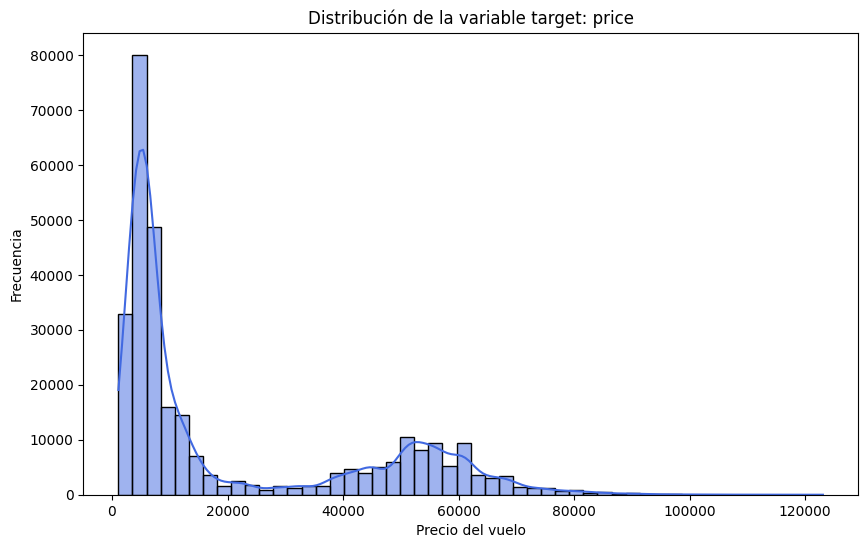

In [89]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final[target_reg], bins=50, kde=True, color='royalblue')
plt.title("Distribución de la variable target: price")
plt.xlabel("Precio del vuelo")
plt.ylabel("Frecuencia")
plt.show()

*'Price' presenta una distribución asimétrica. Hay un pico en valores bajos (clase económica) y una concentración entre 40.000 y 80.000 (que puede ser debido a la clase business). Miro la distribución según la clase:*

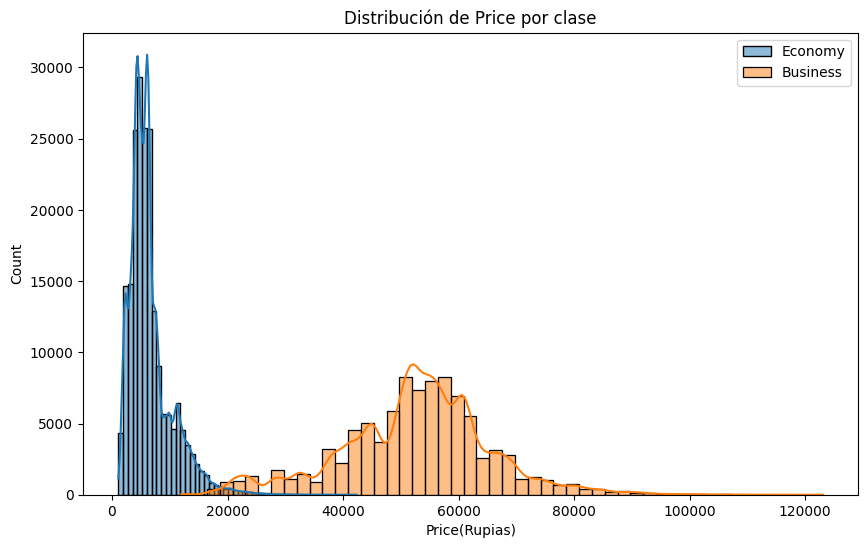

In [90]:
plt.figure(figsize=(10, 6))
sns.histplot(df_final[df_final["class"] == "economy"][target_reg], bins=50, kde=True, label = "Economy")
sns.histplot(df_final[df_final["class"] == "business"][target_reg], bins=50, kde=True, label = "Business")
plt.title("Distribución de Price por clase")
plt.xlabel("Price(Rupias)")
plt.legend()
plt.show()

**MINI-EDA**

In [91]:
df_final.columns

Index(['airline', 'source_city', 'destination_city', 'price(Rupias)',
       'duration(h)', 'dep_time_cat', 'arr_time_cat', 'days_left', 'class',
       'stop_num'],
      dtype='object')

In [92]:
features_num_reg = ["duration(h)", "days_left", "stop_num"]
print(features_num_reg)

features_cat_reg = [col for col in df_final.columns if col not in features_num_reg and col != target_reg]
print(features_cat_reg)

features = features_num_reg + features_cat_reg

['duration(h)', 'days_left', 'stop_num']
['airline', 'source_city', 'destination_city', 'dep_time_cat', 'arr_time_cat', 'class']


Categóricas vs target_reg

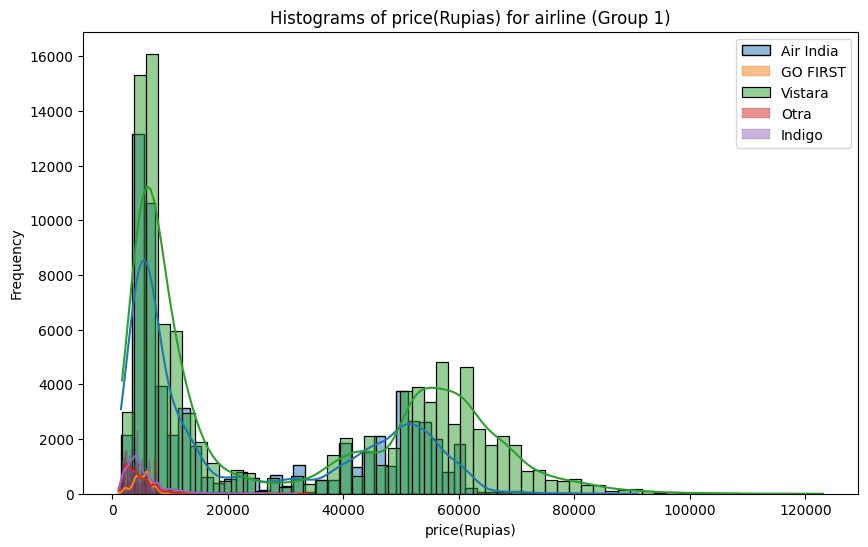

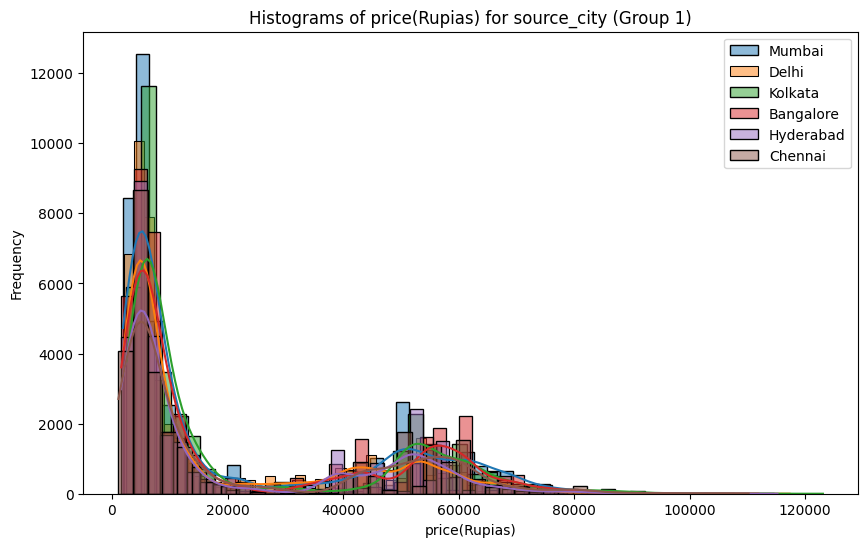

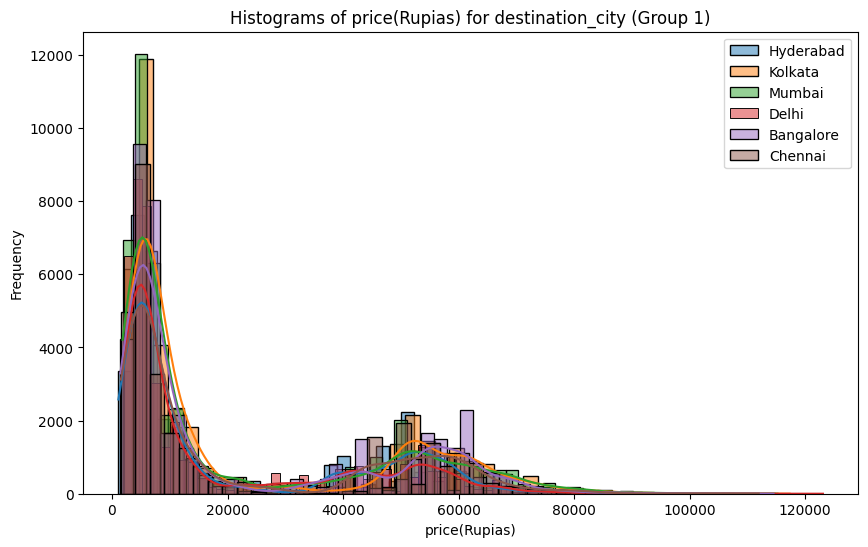

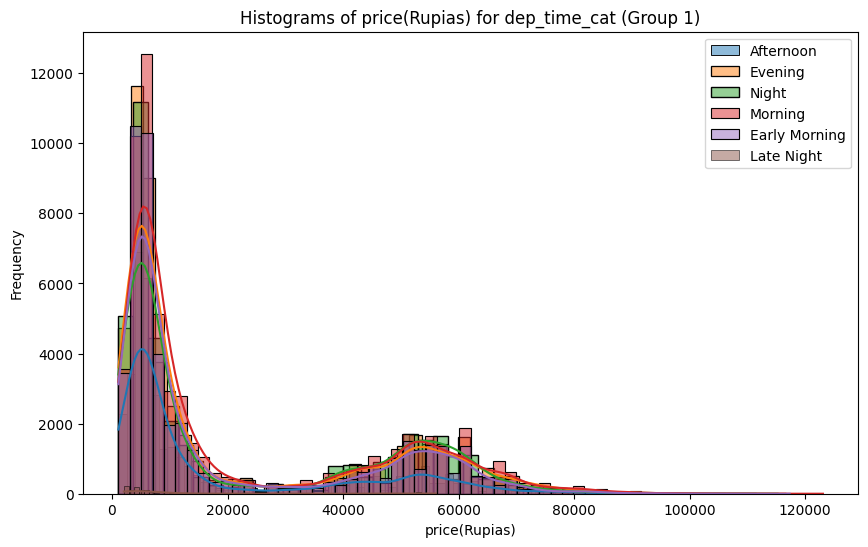

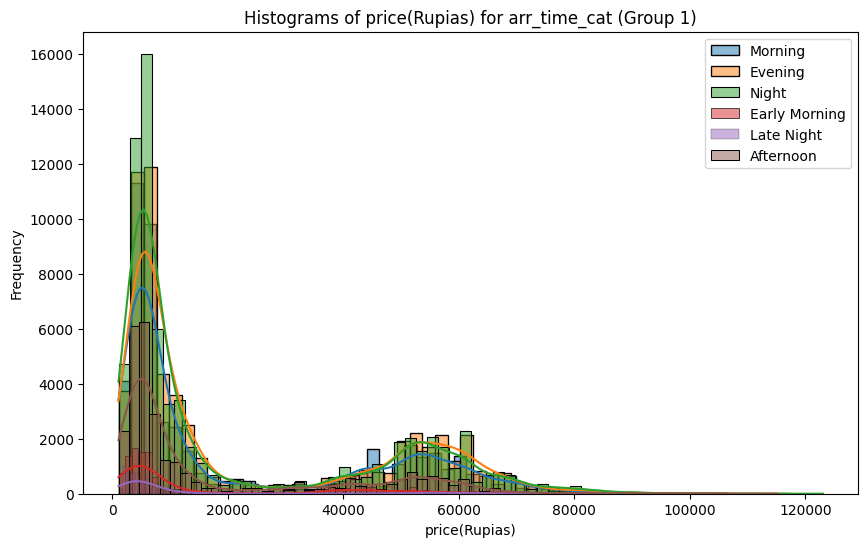

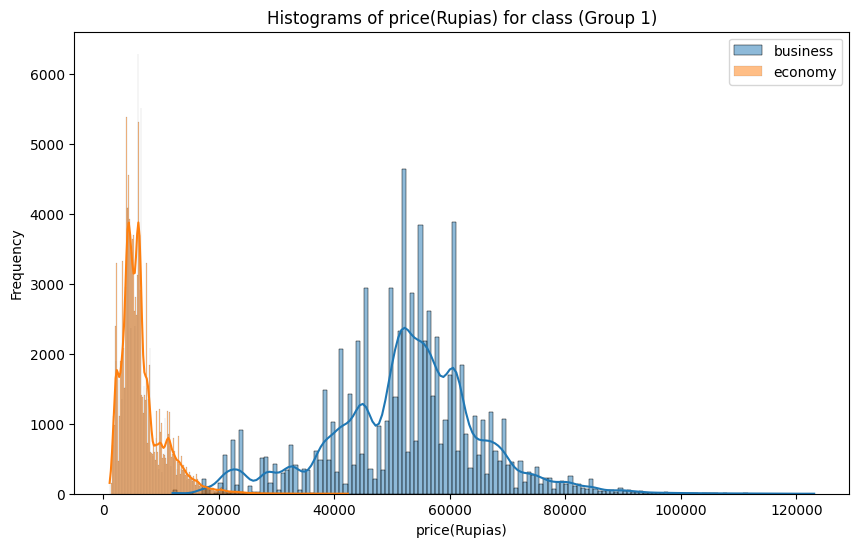

In [93]:
for col_cat in features_cat_reg:
    bt.plot_grouped_histograms(train_set, cat_col= col_cat, num_col= target_reg, group_size= train_set[col_cat].nunique())

*Las distribuciones de 'dep_time_cat' y 'arr_time_cat' son las que más superpuestas parecen*.

Lo hago también con el test ANOVA para decidir si me quedo todas o no.

In [94]:
for cat_col in features_cat_reg:
    valores_unicos = train_set[cat_col].unique()
    target_por_cat_col = [train_set[train_set[cat_col] == categoria][target_reg] for categoria in valores_unicos]

    f_val, p_val = stats.f_oneway(*target_por_cat_col)
    print(f"{cat_col}:")
    print(f"\t Valor de F: {f_val}")
    print(f"\t p-valor: {p_val}")

airline:
	 Valor de F: 17081.57235488204
	 p-valor: 0.0
source_city:
	 Valor de F: 111.43991654629089
	 p-valor: 4.913557666382573e-118
destination_city:
	 Valor de F: 142.45408569181038
	 p-valor: 1.8474400472304373e-151
dep_time_cat:
	 Valor de F: 258.3793846974706
	 p-valor: 2.0616262378244465e-276
arr_time_cat:
	 Valor de F: 762.2266222223897
	 p-valor: 0.0
class:
	 Valor de F: 1753340.457890602
	 p-valor: 0.0


*Todos los p-valores son muy pequeños (p-valor < 0.01), se puede rechazar la hipótesis nula de que no existe relación entre las variables, así que me quedo con todas.*

Numéricas vs target_reg

In [95]:
# Correlaciones
corr = train_set[features_num_reg + [target_reg]].corr()
serie_corr = np.abs(corr[target_reg]).sort_values(ascending = False)
serie_corr

price(Rupias)    1.000000
duration(h)      0.200939
stop_num         0.114994
days_left        0.091964
Name: price(Rupias), dtype: float64

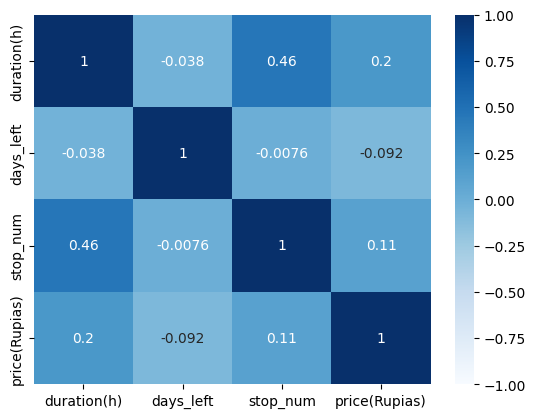

In [96]:
plt.figure()
sns.heatmap(corr, annot= True, cmap = "Blues", vmin= -1, vmax= 1);

- *No correla mucho ninguna variable con el target.*
- *Entre 'stop_num' y 'duration' sí hay cierta colinealidad.*

Como son muy pocas y 0.46 no es mucho, creo que es mejor quedarse con todas.

**Tratamiento de features**

Categóricas

In [97]:
features_cat_reg

['airline',
 'source_city',
 'destination_city',
 'dep_time_cat',
 'arr_time_cat',
 'class']

In [128]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set["class"] = ord_encoder.fit_transform(train_set[["class"]])
test_set["class"] = ord_encoder.transform(test_set[["class"]])

In [129]:
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set[cat_cols])
test_encod = OH_encoder.transform(test_set[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set.index)

In [130]:
resto_cols = [col for col in features if col not in cat_cols]
resto_cols

['duration(h)', 'days_left', 'stop_num', 'class']

In [131]:
train_set = pd.concat([train_set[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set = pd.concat([test_set[resto_cols + [target_reg]], test_encod_df], axis = 1)

In [102]:
print(train_set.shape)
print(test_set.shape)

(238553, 34)
(59639, 34)


In [103]:
train_set.head()

,duration(h),days_left,stop_num,class,price(Rupias),airline_Air India,airline_GO FIRST,airline_Indigo,airline_Otra,airline_Vistara,...,dep_time_cat_Evening,dep_time_cat_Late Night,dep_time_cat_Morning,dep_time_cat_Night,arr_time_cat_Afternoon,arr_time_cat_Early Morning,arr_time_cat_Evening,arr_time_cat_Late Night,arr_time_cat_Morning,arr_time_cat_Night
239454,17.583333,48,1,1.0,45693.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
21379,12.750000,12,1,0.0,5954.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
262332,21.500000,7,1,1.0,50271.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
85586,11.166667,15,1,0.0,10954.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
58841,1.750000,40,0,0.0,2074.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Numéricas

In [103]:
# train_set_scaled = train_set.copy()
# test_set_scaled = test_set.copy()

In [104]:
# train_set[features_num_reg].hist()
# plt.tight_layout()

In [105]:
# train_set["duration(h)"].apply(np.log).hist();

In [106]:
# # Aplico logaritmo a duration
# train_set_scaled["duration(h)"] = np.log(train_set_scaled["duration(h)"])
# test_set_scaled["duration(h)"] = np.log(test_set_scaled["duration(h)"])

Escalado

In [107]:
# scaler = StandardScaler()
# train_set_scaled[features_num_reg] = scaler.fit_transform(train_set_scaled[features_num_reg])
# test_set_scaled[features_num_reg] = scaler.transform(test_set_scaled[features_num_reg])

In [108]:
# train_set_scaled[features_num_reg].describe()

**Modelado**

Parejas X e y

In [132]:
X_train = train_set.drop(columns= target_reg, axis = 1)
# X_train_scaled = train_set_scaled.drop(columns= target_reg, axis = 1)
y_train = train_set[target_reg]

X_test = test_set.drop(columns= target_reg, axis = 1)
# X_test_scaled = test_set_scaled.drop(columns= target_reg, axis = 1)
y_test = test_set[target_reg]

Baseline

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)

Comparación

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)
lgb_reg = LGBMRegressor(max_depth = 5, random_state = 42, verbose = -1)
xgb_reg = XGBRegressor(max_depth = 5, random_state = 42)

modelos_reg = {
    "Random Forest": rf_reg,
    "LightGBM": lgb_reg,
    "XGBoost Regressor": xgb_reg
}

model_set = [rf_reg, xgb_reg, lgb_reg]

In [134]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, modelo in zip(modelos_reg, model_set):
    valores = cross_validate(modelo, X_train, y_train, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

Model <Random Forest>:
	 RMSE_CV: 5443.622707765202
	 MAE_CV: 3216.752553013316
	 R2-score_CV: 0.9426503223351826
Model <LightGBM>:
	 RMSE_CV: 3830.711490587005
	 MAE_CV: 2241.6684405876017
	 R2-score_CV: 0.971600117830433
Model <XGBoost Regressor>:
	 RMSE_CV: 4359.959460025896
	 MAE_CV: 2548.112837877526
	 R2-score_CV: 0.9632073856975607


*El mejor en todas las métricas es LightGBM*

In [120]:
param_grid_lgb = {
    "n_estimators": [100,200],
    "learning_rate": [0.1,0.5,1],
    "max_depth": [5,10,15],
    "min_data_in_leaf": [1,10,20,100]
}

lgb_reg = LGBMRegressor(verbose = -1)

lgb_grid = GridSearchCV(lgb_reg,
                        param_grid= param_grid_lgb,
                        cv = 5,
                        scoring= "neg_root_mean_squared_error",
                        n_jobs=-1)

lgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(verbose=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.5, ...], 'max_depth': [5, 10, ...], 'min_data_in_leaf': [1, 10, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for eac

In [121]:
-lgb_grid.best_score_

np.float64(2920.6729414321503)

In [122]:
lgb_grid.best_params_

{'learning_rate': 0.5,
 'max_depth': 15,
 'min_data_in_leaf': 10,
 'n_estimators': 200}

In [124]:
y_pred_test = lgb_grid.best_estimator_.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred_test))
print("MAE:", mean_absolute_error(y_test, y_pred_test))
print("R2:", r2_score(y_test, y_pred_test))

RMSE: 2906.9205619190316
MAE: 1653.369112264242
R2: 0.9836332795919495


In [119]:
def plot_predictions_vs_actual(y_real, y_pred):
    """
    Función para graficar los valores reales vs. los valores predichos en una regresión.

    Args:
    y_real (array-like): Valores reales de la variable objetivo.
    y_pred (array-like): Valores predichos de la variable objetivo.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_pred, y_real, alpha=0.5)
    plt.xlabel("Valores Predichos")
    plt.ylabel("Valores Reales")

    # Línea y=x
    max_value = max(max(y_real), max(y_pred))
    min_value = min(min(y_real), min(y_pred))
    plt.plot([min_value, max_value], [min_value, max_value], 'r')

    plt.title("Comparación de Valores Reales vs. Predichos")
    plt.show()

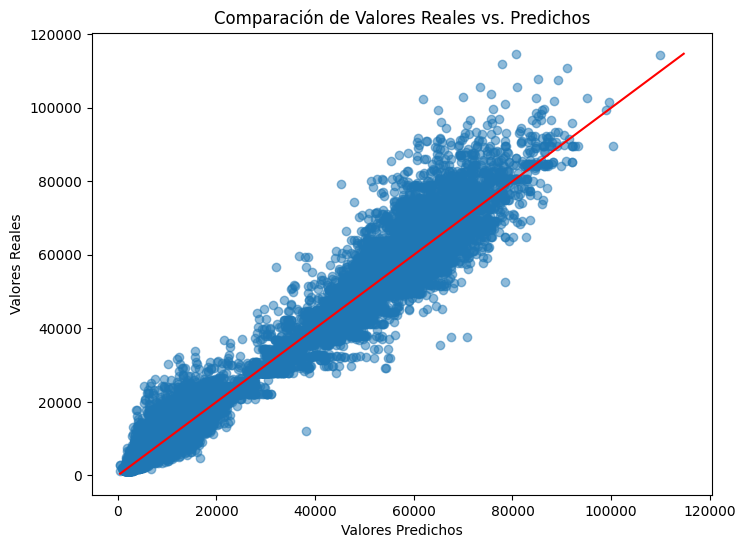

In [111]:
plot_predictions_vs_actual(y_test, y_pred_test)

**Optimización con optuna**

In [177]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "num_leaves": trial.suggest_int("num_leaves", 7, 260),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300) # 10 y 200
    }

    model = LGBMRegressor(**param_grid, random_state= 42, verbose = -1)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [178]:
# Crear y ejecutar estudy de Optuna
# segundo
study = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

[I 2026-02-28 20:08:20,364] A new study created in memory with name: no-name-036b9818-584d-44aa-a4ca-8bed9d6f33dd


In [179]:
study.optimize(objective, n_trials= 200) # optimizar el estudio

[I 2026-02-28 20:09:30,383] Trial 0 finished with value: 3276.9397182617927 and parameters: {'n_estimators': 362, 'max_depth': 8, 'num_leaves': 192, 'learning_rate': 0.0638792635777333, 'min_data_in_leaf': 89}. Best is trial 0 with value: 3276.9397182617927.
[I 2026-02-28 20:09:45,361] Trial 1 finished with value: 4908.751925293485 and parameters: {'n_estimators': 209, 'max_depth': 3, 'num_leaves': 227, 'learning_rate': 0.0641003510568888, 'min_data_in_leaf': 227}. Best is trial 0 with value: 3276.9397182617927.
[I 2026-02-28 20:10:03,667] Trial 2 finished with value: 4265.642311894122 and parameters: {'n_estimators': 114, 'max_depth': 8, 'num_leaves': 218, 'learning_rate': 0.029110519961044856, 'min_data_in_leaf': 95}. Best is trial 0 with value: 3276.9397182617927.
[I 2026-02-28 20:10:15,080] Trial 3 finished with value: 4664.050757202376 and parameters: {'n_estimators': 228, 'max_depth': 4, 'num_leaves': 140, 'learning_rate': 0.048875051677790424, 'min_data_in_leaf': 123}. Best is t

In [ ]:
# 2
study.best_trial

FrozenTrial(number=179, state=<TrialState.COMPLETE: 1>, values=[2831.5827144657837], datetime_start=datetime.datetime(2026, 2, 28, 22, 35, 39, 234119), datetime_complete=datetime.datetime(2026, 2, 28, 22, 36, 2, 454332), params={'n_estimators': 779, 'max_depth': 8, 'num_leaves': 143, 'learning_rate': 0.09782614207361737, 'min_data_in_leaf': 71}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=800, log=False, low=100, step=1), 'max_depth': IntDistribution(high=8, log=False, low=3, step=1), 'num_leaves': IntDistribution(high=260, log=False, low=7, step=1), 'learning_rate': FloatDistribution(high=0.1, log=False, low=0.01, step=None), 'min_data_in_leaf': IntDistribution(high=300, log=False, low=50, step=1)}, trial_id=179, value=None)

In [181]:
# 2
study.best_value

2831.5827144657837

In [182]:
best_params = study.best_params
best_params

{'n_estimators': 779,
 'max_depth': 8,
 'num_leaves': 143,
 'learning_rate': 0.09782614207361737,
 'min_data_in_leaf': 71}

In [183]:
best_model = LGBMRegressor(**best_params, random_state= 42, verbose = -1)

In [184]:
best_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,143
,max_depth,8
,learning_rate,0.09782614207361737
,n_estimators,779
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [187]:
y_pred = best_model.predict(X_train)
print("RMSE:", root_mean_squared_error(y_train, y_pred))
print("MAE:", mean_absolute_error(y_train, y_pred))
print("R2:", r2_score(y_train, y_pred))

RMSE: 2503.634825217787
MAE: 1364.7030431620844
R2: 0.9878699869872113


In [185]:
y_pred = best_model.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

RMSE: 2771.645560214177
MAE: 1492.8784021024965
R2: 0.9851211036293711


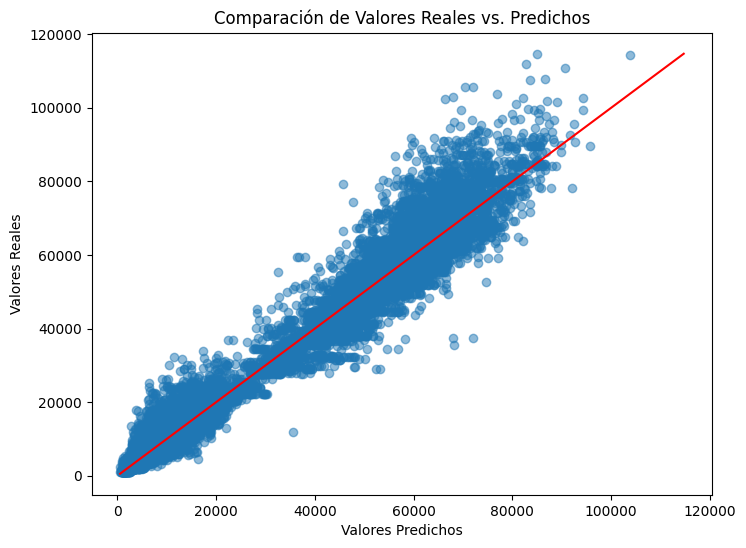

In [186]:
plot_predictions_vs_actual(y_test, y_pred)

In [188]:
joblib.dump(best_model, "lgbm_best_model_2.joblib")

['lgbm_best_model_2.joblib']

----

In [105]:
# Crear y ejecutar estudy de Optuna
study = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

[I 2026-02-26 20:22:11,406] A new study created in memory with name: no-name-ed53bb79-2d32-466d-b5d0-2e8162d26557


In [127]:
study.optimize(objective, n_trials= 200) # optimizar el estudio

[I 2026-02-25 11:15:06,984] Trial 0 finished with value: 2679.1336040451724 and parameters: {'n_estimators': 362, 'max_depth': 15, 'num_leaves': 192, 'learning_rate': 0.6187255599871848, 'min_data_in_leaf': 39}. Best is trial 0 with value: 2679.1336040451724.
[I 2026-02-25 11:15:21,308] Trial 1 finished with value: 3431.061472453521 and parameters: {'n_estimators': 209, 'max_depth': 5, 'num_leaves': 227, 'learning_rate': 0.6210592611560484, 'min_data_in_leaf': 145}. Best is trial 0 with value: 2679.1336040451724.
[I 2026-02-25 11:15:39,056] Trial 2 finished with value: 2763.3814526911847 and parameters: {'n_estimators': 114, 'max_depth': 15, 'num_leaves': 218, 'learning_rate': 0.25172215514436236, 'min_data_in_leaf': 44}. Best is trial 0 with value: 2679.1336040451724.
[I 2026-02-25 11:15:55,060] Trial 3 finished with value: 2775.3930370361604 and parameters: {'n_estimators': 228, 'max_depth': 8, 'num_leaves': 140, 'learning_rate': 0.46034776771000996, 'min_data_in_leaf': 65}. Best is 

In [140]:
optuna.visualization.plot_param_importances(study)

In [139]:
study.best_value

2489.336126952272

In [132]:
best_params = study.best_params
best_params

{'n_estimators': 800,
 'max_depth': 15,
 'num_leaves': 244,
 'learning_rate': 0.12429092072713381,
 'min_data_in_leaf': 10}

In [134]:
best_model = LGBMRegressor(**best_params, random_state= 42, verbose = -1)

In [135]:
best_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,244
,max_depth,15
,learning_rate,0.12429092072713381
,n_estimators,800
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [136]:
y_pred = best_model.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

RMSE: 2383.622356575259
MAE: 1159.5781742091317
R2: 0.9889955019964942


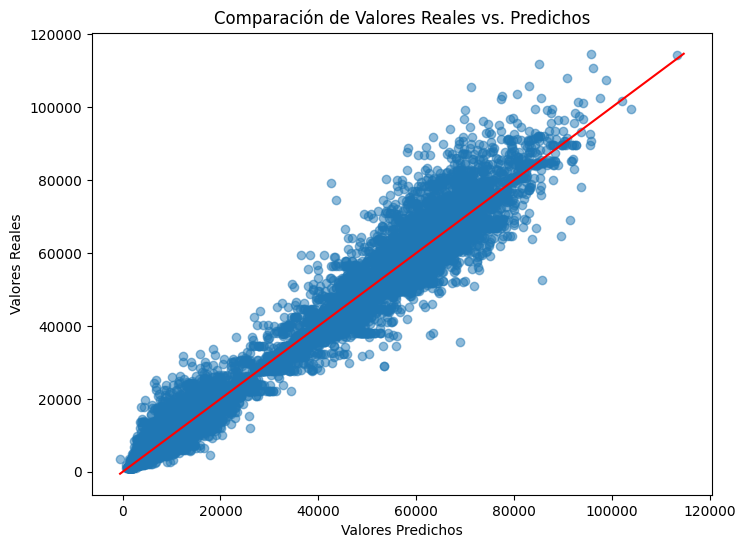

In [146]:
plot_predictions_vs_actual(y_test, y_pred)

Guardo el modelo:

In [74]:
joblib.dump(best_model, "lgbm_best_model.joblib")

NameError: name 'best_model' is not defined

In [97]:
modelo = joblib.load("lgbm_best_model.joblib")

In [111]:
mask_econ = X_train["class"] == 0
mask_bus = X_train["class"] == 1

y_pred = modelo.predict(X_train)
print("RMSE:", root_mean_squared_error(y_train[mask_econ], y_pred[mask_econ]))
print("MAE:", mean_absolute_error(y_train[mask_econ], y_pred[mask_econ]))
print("R2:", r2_score(y_train[mask_econ], y_pred[mask_econ]))

RMSE: 959.1090496130238
MAE: 566.6575441512105
R2: 0.9341490400599268


In [99]:
mask_econ = X_test["class"] == 0
mask_bus = X_test["class"] == 1

y_pred = modelo.predict(X_test)
print("RMSE:", root_mean_squared_error(y_test[mask_econ], y_pred[mask_econ]))
print("MAE:", mean_absolute_error(y_test[mask_econ], y_pred[mask_econ]))
print("R2:", r2_score(y_test[mask_econ], y_pred[mask_econ]))

RMSE: 1356.152713175391
MAE: 742.760479832018
R2: 0.8721959274156338


In [112]:
y_pred = modelo.predict(X_train)
print("RMSE:", root_mean_squared_error(y_train[mask_bus], y_pred[mask_bus]))
print("MAE:", mean_absolute_error(y_train[mask_bus], y_pred[mask_bus]))
print("R2:", r2_score(y_train[mask_bus], y_pred[mask_bus]))

RMSE: 2479.548388278923
MAE: 1392.205745365122
R2: 0.9632240447022992


In [ ]:
# Business
print("RMSE:", root_mean_squared_error(y_test[mask_bus], y_pred[mask_bus]))
print("MAE:", mean_absolute_error(y_test[mask_bus], y_pred[mask_bus]))
print("R2:", r2_score(y_test[mask_bus], y_pred[mask_bus]))

RMSE: 3765.853034519489
MAE: 2081.619233263196
R2: 0.9153923021076397


----

**Economy**

In [104]:
train_set_eco, test_set_eco = train_test_split(df_eco, test_size= 0.2, random_state= 42)

In [105]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set_eco["class"] = ord_encoder.fit_transform(train_set_eco[["class"]])
test_set_eco["class"] = ord_encoder.transform(test_set_eco[["class"]])
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set_eco[cat_cols])
test_encod = OH_encoder.transform(test_set_eco[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set_eco.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set_eco.index)
resto_cols = [col for col in features if col not in cat_cols]
resto_cols
train_set_eco = pd.concat([train_set_eco[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set_eco = pd.concat([test_set_eco[resto_cols + [target_reg]], test_encod_df], axis = 1)

In [106]:
X_train_eco = train_set_eco.drop(columns=target_reg, axis = 1)
X_test_eco = test_set_eco.drop(columns = target_reg, axis = 1)

y_train_eco = train_set_eco[target_reg]
y_test_eco = test_set_eco[target_reg]

In [ ]:
rf_reg = RandomForestRegressor(max_depth = 5, random_state= 42)
lgb_reg = LGBMRegressor(max_depth = 5, random_state = 42, verbose = -1)
xgb_reg = XGBRegressor(max_depth = 5, random_state = 42)

modelos_reg = {
    "Random Forest": rf_reg,
    "LightGBM": lgb_reg,
    "XGBoost Regressor": xgb_reg
}

model_set = [rf_reg, xgb_reg, lgb_reg]

In [ ]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, modelo in zip(modelos_reg, model_set):
    valores = cross_validate(modelo, X_train_eco, y_train_eco, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

Model <Random Forest>:
	 RMSE_CV: 2233.354159610636
	 MAE_CV: 1465.3794417304289
	 R2-score_CV: 0.6421726198160738
Model <LightGBM>:
	 RMSE_CV: 1765.240673828125
	 MAE_CV: 1103.3179443359375
	 R2-score_CV: 0.776444411277771
Model <XGBoost Regressor>:
	 RMSE_CV: 1899.8034682535392
	 MAE_CV: 1218.305540003746
	 R2-score_CV: 0.7410751855021325


In [107]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "num_leaves": trial.suggest_int("num_leaves", 7, 260),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300) # 10 y 200
    }

    model = LGBMRegressor(**param_grid, random_state= 42, verbose = -1)

    score = cross_val_score(
        model,
        X_train_eco,
        y_train_eco,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [108]:
# Crear y ejecutar estudy de Optuna
study_eco = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

[I 2026-02-28 17:53:14,029] A new study created in memory with name: no-name-9c330f8e-f279-4925-963a-8677103c22d6


In [109]:
study_eco.optimize(objective, n_trials= 200) # optimizar el estudio

[I 2026-02-28 17:53:37,883] Trial 0 finished with value: 1638.154289282173 and parameters: {'n_estimators': 362, 'max_depth': 8, 'num_leaves': 192, 'learning_rate': 0.0638792635777333, 'min_data_in_leaf': 89}. Best is trial 0 with value: 1638.154289282173.
[I 2026-02-28 17:53:45,431] Trial 1 finished with value: 2044.9466202175397 and parameters: {'n_estimators': 209, 'max_depth': 3, 'num_leaves': 227, 'learning_rate': 0.0641003510568888, 'min_data_in_leaf': 227}. Best is trial 0 with value: 1638.154289282173.
[I 2026-02-28 17:53:56,225] Trial 2 finished with value: 1903.6243288665682 and parameters: {'n_estimators': 114, 'max_depth': 8, 'num_leaves': 218, 'learning_rate': 0.029110519961044856, 'min_data_in_leaf': 95}. Best is trial 0 with value: 1638.154289282173.
[I 2026-02-28 17:54:03,097] Trial 3 finished with value: 1980.987955482716 and parameters: {'n_estimators': 228, 'max_depth': 4, 'num_leaves': 140, 'learning_rate': 0.048875051677790424, 'min_data_in_leaf': 123}. Best is tri

In [110]:
study_eco.best_value

1489.8842314882017

In [111]:
best_params_eco = study_eco.best_params
best_params_eco

{'n_estimators': 721,
 'max_depth': 8,
 'num_leaves': 121,
 'learning_rate': 0.09977437405566834,
 'min_data_in_leaf': 64}

In [112]:
best_model_eco = LGBMRegressor(**best_params_eco, random_state= 42, verbose = -1)

In [113]:
best_model_eco.fit(X_train_eco, y_train_eco)

,boosting_type,'gbdt'
,num_leaves,121
,max_depth,8
,learning_rate,0.09977437405566834
,n_estimators,721
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [155]:
y_pred_eco = best_model_eco.predict(X_train_eco)
print("RMSE:", root_mean_squared_error(y_train_eco, y_pred_eco))
print("MAE:", mean_absolute_error(y_train_eco, y_pred_eco))
print("R2:", r2_score(y_train_eco, y_pred_eco))

RMSE: 1293.7333540731167
MAE: 752.7849721725358
R2: 0.8799340344323481


In [114]:
y_pred_eco = best_model_eco.predict(X_test_eco)
print("RMSE:", root_mean_squared_error(y_test_eco, y_pred_eco))
print("MAE:", mean_absolute_error(y_test_eco, y_pred_eco))
print("R2:", r2_score(y_test_eco, y_pred_eco))

RMSE: 1486.7721834996128
MAE: 844.7868102518682
R2: 0.8476266741536753


In [165]:
train_set_eco.describe()["price(Rupias)"]

count    164012.000000
mean       6582.658604
std        3733.671804
min        1105.000000
25%        4190.000000
50%        5788.000000
75%        7766.000000
max       42349.000000
Name: price(Rupias), dtype: float64

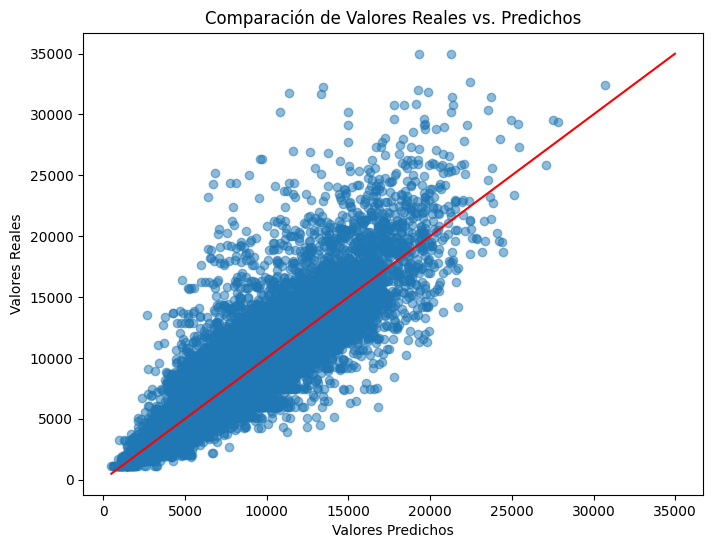

In [120]:
plot_predictions_vs_actual(y_test_eco, y_pred_eco)

In [189]:
joblib.dump(best_model_eco, "lgbm_best_model_eco.joblib")

['lgbm_best_model_eco.joblib']

**Business**

In [149]:
train_set_bus, test_set_bus = train_test_split(df_bus, test_size= 0.2, random_state= 42)

In [150]:
ord_encoder = OrdinalEncoder(categories= [["economy", "business"]])
train_set_bus["class"] = ord_encoder.fit_transform(train_set_bus[["class"]])
test_set_bus["class"] = ord_encoder.transform(test_set_bus[["class"]])
OH_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

cat_cols = [col for col in features_cat_reg if col != "class"]

train_encod = OH_encoder.fit_transform(train_set_bus[cat_cols])
test_encod = OH_encoder.transform(test_set_bus[cat_cols])

# Convertimos a DataFrame con nombres de columna
col_names = OH_encoder.get_feature_names_out(cat_cols)
train_encod_df = pd.DataFrame(train_encod, columns = col_names, index = train_set_bus.index)
test_encod_df = pd.DataFrame(test_encod, columns = col_names, index = test_set_bus.index)
resto_cols = [col for col in features if col not in cat_cols]
resto_cols
train_set_bus = pd.concat([train_set_bus[resto_cols + [target_reg]], train_encod_df], axis = 1)
test_set_bus = pd.concat([test_set_bus[resto_cols + [target_reg]], test_encod_df], axis = 1)

In [151]:
X_train_bus= train_set_bus.drop(columns=target_reg, axis = 1)
X_test_bus = test_set_bus.drop(columns = target_reg, axis = 1)

y_train_bus = train_set_bus[target_reg]
y_test_bus = test_set_bus[target_reg]

In [174]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, modelo in zip(modelos_reg, model_set):
    valores = cross_validate(modelo, X_train_bus, y_train_bus, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

Model <Random Forest>:
	 RMSE_CV: 8812.849862692183
	 MAE_CV: 6484.5142907816335
	 R2-score_CV: 0.5352579120578754
Model <LightGBM>:
	 RMSE_CV: 5566.49658203125
	 MAE_CV: 3845.72275390625
	 R2-score_CV: 0.8145875811576844
Model <XGBoost Regressor>:
	 RMSE_CV: 6728.8355172799365
	 MAE_CV: 4850.469503449883
	 R2-score_CV: 0.7290651096191049


In [152]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),  # 5 y 15
        "num_leaves": trial.suggest_int("num_leaves", 7, 260),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1), # 0.05 y 1
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300) # 10 y 200
    }

    model = LGBMRegressor(**param_grid, random_state= 42, verbose = -1)

    score = cross_val_score(
        model,
        X_train_bus,
        y_train_bus,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [153]:
# Crear y ejecutar estudy de Optuna
study_bus = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

[I 2026-02-28 18:54:20,435] A new study created in memory with name: no-name-33a0d68f-a6dc-47dc-b741-2da99ba08eb1


In [154]:
study_bus.optimize(objective, n_trials= 200) # optimizar el estudio

[I 2026-02-28 18:54:49,307] Trial 0 finished with value: 5097.104124303341 and parameters: {'n_estimators': 362, 'max_depth': 8, 'num_leaves': 192, 'learning_rate': 0.0638792635777333, 'min_data_in_leaf': 89}. Best is trial 0 with value: 5097.104124303341.
[I 2026-02-28 18:55:01,425] Trial 1 finished with value: 7687.611188229242 and parameters: {'n_estimators': 209, 'max_depth': 3, 'num_leaves': 227, 'learning_rate': 0.0641003510568888, 'min_data_in_leaf': 227}. Best is trial 0 with value: 5097.104124303341.
[I 2026-02-28 18:55:10,740] Trial 2 finished with value: 6712.069837478795 and parameters: {'n_estimators': 114, 'max_depth': 8, 'num_leaves': 218, 'learning_rate': 0.029110519961044856, 'min_data_in_leaf': 95}. Best is trial 0 with value: 5097.104124303341.
[I 2026-02-28 18:55:12,915] Trial 3 finished with value: 7256.216441457291 and parameters: {'n_estimators': 228, 'max_depth': 4, 'num_leaves': 140, 'learning_rate': 0.048875051677790424, 'min_data_in_leaf': 123}. Best is trial

In [167]:
study_bus.best_value

4300.317529511474

In [168]:
best_params_bus = study_bus.best_params
best_params_bus

{'n_estimators': 799,
 'max_depth': 8,
 'num_leaves': 110,
 'learning_rate': 0.09994403141640863,
 'min_data_in_leaf': 63}

In [169]:
best_model_bus = LGBMRegressor(**best_params_bus, random_state= 42, verbose = -1)

In [170]:
best_model_bus.fit(X_train_bus, y_train_bus)

,boosting_type,'gbdt'
,num_leaves,110
,max_depth,8
,learning_rate,0.09994403141640863
,n_estimators,799
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [172]:
y_pred_bus = best_model_bus.predict(X_train_bus)
print("RMSE:", root_mean_squared_error(y_train_bus, y_pred_bus))
print("MAE:", mean_absolute_error(y_train_bus, y_pred_bus))
print("R2:", r2_score(y_train_bus, y_pred_bus))

RMSE: 3661.503491842793
MAE: 2235.9615609932953
R2: 0.9197819145034452


In [173]:
y_pred_bus = best_model_bus.predict(X_test_bus)
print("RMSE:", root_mean_squared_error(y_test_bus, y_pred_bus))
print("MAE:", mean_absolute_error(y_test_bus, y_pred_bus))
print("R2:", r2_score(y_test_bus, y_pred_bus))

RMSE: 4137.880842069073
MAE: 2527.466270529877
R2: 0.8979741203270123


In [175]:
train_set_bus.describe()["price(Rupias)"]

count     74540.000000
mean      52609.435954
std       12927.847471
min       12000.000000
25%       45228.000000
50%       53164.000000
75%       60396.000000
max      123071.000000
Name: price(Rupias), dtype: float64

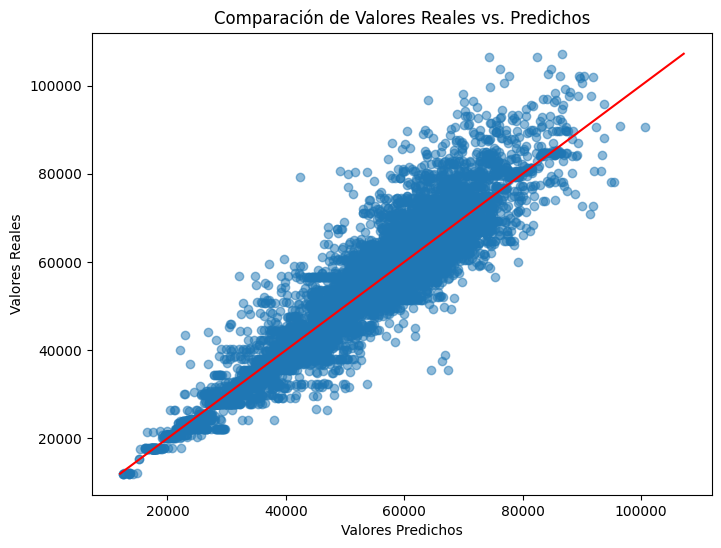

In [176]:
plot_predictions_vs_actual(y_test_bus, y_pred_bus)

In [190]:
joblib.dump(best_model_bus, "lgbm_best_model_bus.joblib")

['lgbm_best_model_bus.joblib']

----

**Con pipeline**

In [101]:
X_train_pipe = train_set_copy.drop(columns= target_reg, axis = 1)
y_train_pipe = train_set_copy[target_reg]

X_test_pipe = test_set_copy.drop(columns= target_reg, axis = 1)
y_test_pipe = test_set_copy[target_reg]

In [105]:
categorias = [["economy", "business"]]
cat_cols = [col for col in features_cat_reg if col != "class"]

preprocesing = ColumnTransformer([
    ("procesar_cat_ord", OrdinalEncoder(categories = categorias, handle_unknown = "use_encoded_value", unknown_value = -1), ["class"]),
    ("procesar_cat_OH", OneHotEncoder(handle_unknown = "ignore"), cat_cols)
], remainder = "passthrough")

In [108]:
rf_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", RandomForestRegressor())
])

lgb_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", LGBMRegressor())
])

xgb_pipeline = Pipeline([
    ("preprocesado", preprocesing),
    ("modelo", XGBRegressor())
])

modelos = {
    "rf": rf_pipeline,
    "lgb": lgb_pipeline,
    "xgb": xgb_pipeline
}

In [ ]:
metricas_cv = {}

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

for nombre, pipe in modelos.items():
    valores = cross_validate(pipe, X_train_pipe, y_train_pipe, cv = 5, scoring = scoring)
    metricas_cv[nombre] = valores


for model_name, valores in metricas_cv.items():
    rmse = -np.mean(valores["test_rmse"])
    mae = -np.mean(valores["test_mae"])
    r2 = np.mean(valores["test_r2"])

    print(f"Model <{model_name}>:")
    print(f"\t RMSE_CV: {rmse}")
    print(f"\t MAE_CV: {mae}")
    print(f"\t R2-score_CV: {r2}")

Optimizar con optuna

In [ ]:
# Definir función objetivo para Optuna

def objective(trial):
    param_grid = {
        "modelo__n_estimators": trial.suggest_int("modelo__n_estimators", 100, 800),
        "modelo__max_depth": trial.suggest_int("modelo__max_depth", 5, 15),
        "modelo__num_leaves": trial.suggest_int("modelo__num_leaves", 7, 260),
        "modelo__learning_rate": trial.suggest_float("modelo__learning_rate", 0.05, 1),
        "modelo__min_data_in_leaf": trial.suggest_int("modelo__min_data_in_leaf", 10, 200)
    }

    lgb_pipeline.set_params(**param_grid)

    score = cross_val_score(
        lgb_pipeline,
        X_train,
        y_train,
        cv = 5,
        scoring = "neg_root_mean_squared_error",
        n_jobs = -1
    ).mean()

    return -score

In [ ]:
study_pipe = optuna.create_study(direction="minimize")
study_pipe.optimize(objective, n_trials=50)

In [ ]:
# Crear y ejecutar estudy de Optuna
study_pipe = optuna.create_study(direction = "minimize",
                            sampler = optuna.samplers.TPESampler(seed = 42))

In [ ]:
study_pipe.optimize(objective, n_trials= 200) # optimizar el estudio

In [ ]:
print(study_pipe.best_value)
best_params_pipe = study_pipe.best_params
best_params_pipe

In [ ]:
best_model_pipe = lgb_pipeline.set_params(**best_params_pipe)

best_model_pipe.fit(X_train_pipe, y_train_pipe)

In [ ]:
joblib.dump(best_model_pipe, "lgbm_best_model_pipe.joblib")

In [ ]:
y_pred = best_model_pipe.predict(X_test_pipe)
print("RMSE:", root_mean_squared_error(y_test_pipe, y_pred))
print("MAE:", mean_absolute_error(y_test_pipe, y_pred))
print("R2:", r2_score(y_test_pipe, y_pred))

----

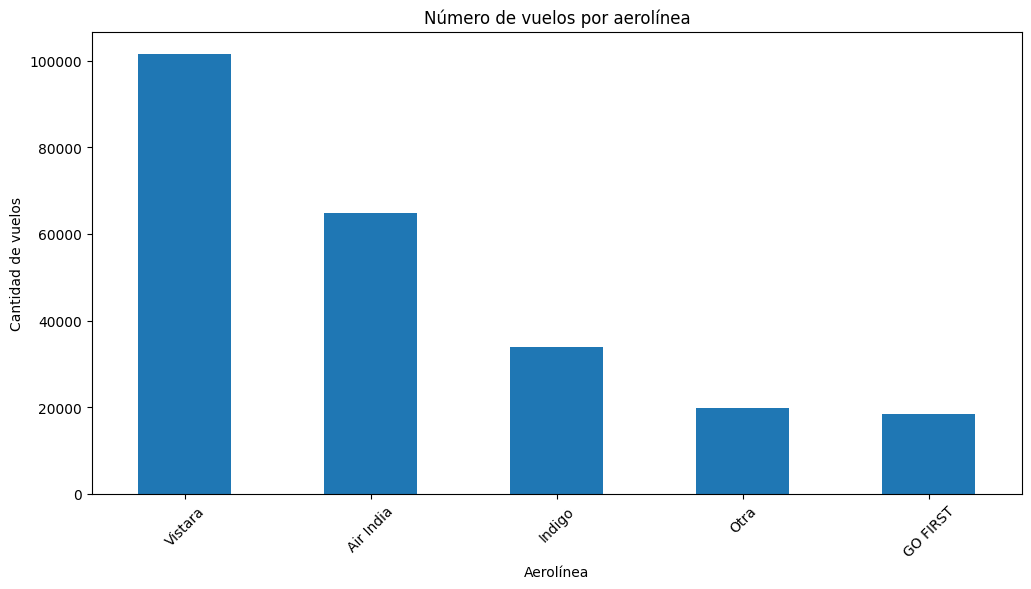

In [289]:
plt.figure(figsize=(12,6))
train_set['airline'].value_counts().plot(kind='bar')
plt.title("Número de vuelos por aerolínea")
plt.xlabel("Aerolínea")
plt.ylabel("Cantidad de vuelos")
plt.xticks(rotation=45)
plt.show()


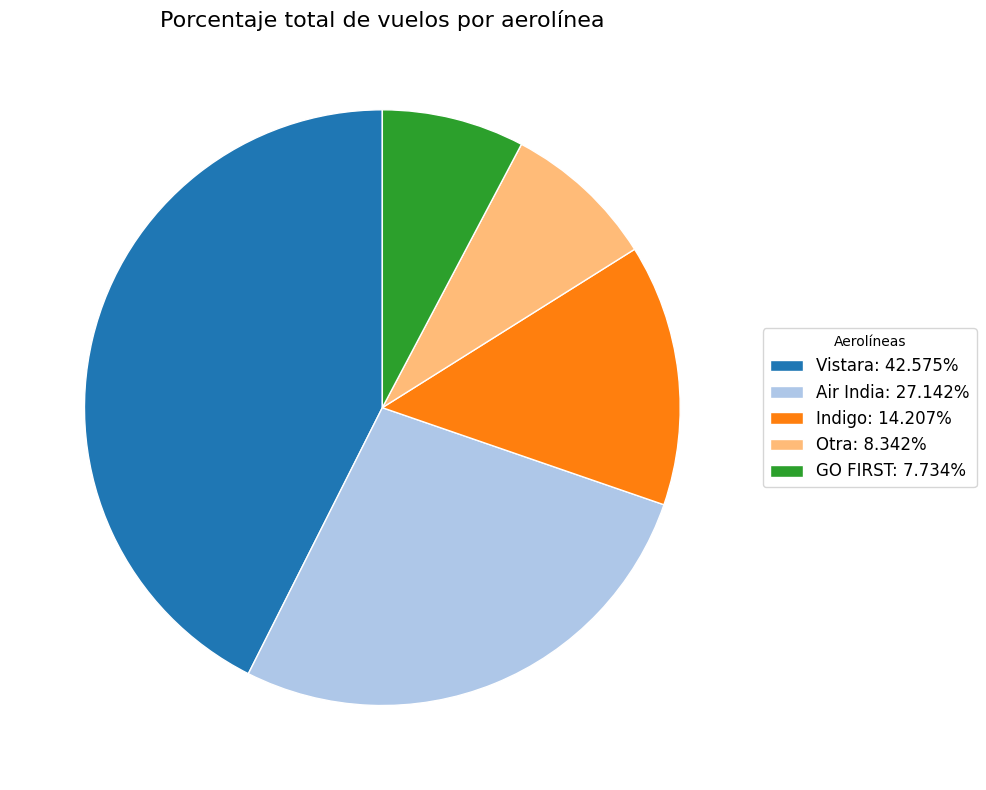

In [290]:
import seaborn as sns
import matplotlib.pyplot as plt

# Conteo y porcentaje
counts = train_set["airline"].value_counts()
percent = counts / counts.sum() * 100

plt.figure(figsize=(10, 8))

# Pie chart
plt.pie(
    counts,
    startangle=90,
    colors=sns.color_palette("tab20"),
    wedgeprops={"linewidth": 1, "edgecolor": "white"}
)

# Leyenda con porcentajes (3 decimales)
labels = [f"{airline}: {pct:.3f}%" for airline, pct in zip(counts.index, percent)]
plt.legend(
    labels,
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=12,
    title="Aerolíneas"
)

plt.title("Porcentaje total de vuelos por aerolínea", fontsize=16)
plt.tight_layout()
plt.show()


Ingresos aproximados por aerolínea

In [291]:
train_set.groupby('airline')['price'].sum().sort_values(ascending=False)

airline
Vistara      3.098865e+09
Air India    1.522199e+09
Indigo       1.809659e+08
GO FIRST     1.043377e+08
Otra         9.638645e+07
Name: price, dtype: float64

El dinero esta en rupias 

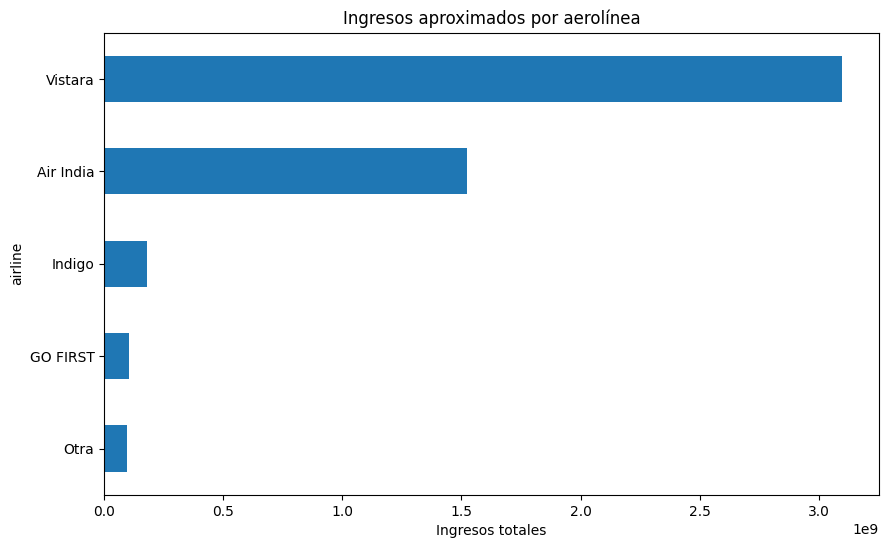

In [292]:
train_set.groupby('airline')['price'].sum().sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Ingresos aproximados por aerolínea")
plt.xlabel("Ingresos totales")
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupar ingresos por aerolínea y clase
income_class = train_set.groupby(['airline', 'class'])['price'].sum().reset_index()

# Calcular porcentaje dentro de cada aerolínea
income_class['percent'] = income_class.groupby('airline')['price'].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=income_class,
    x='airline',
    y='percent',
    hue='class',
    palette='tab10'
)

# Añadir etiquetas de porcentaje encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Porcentaje de ingresos por aerolínea (Economy vs Business)", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje de ingresos (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Porcentaje por aerolinea de vuelos business

C:\Users\lufue\AppData\Local\Temp\ipykernel_17540\4032887624.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


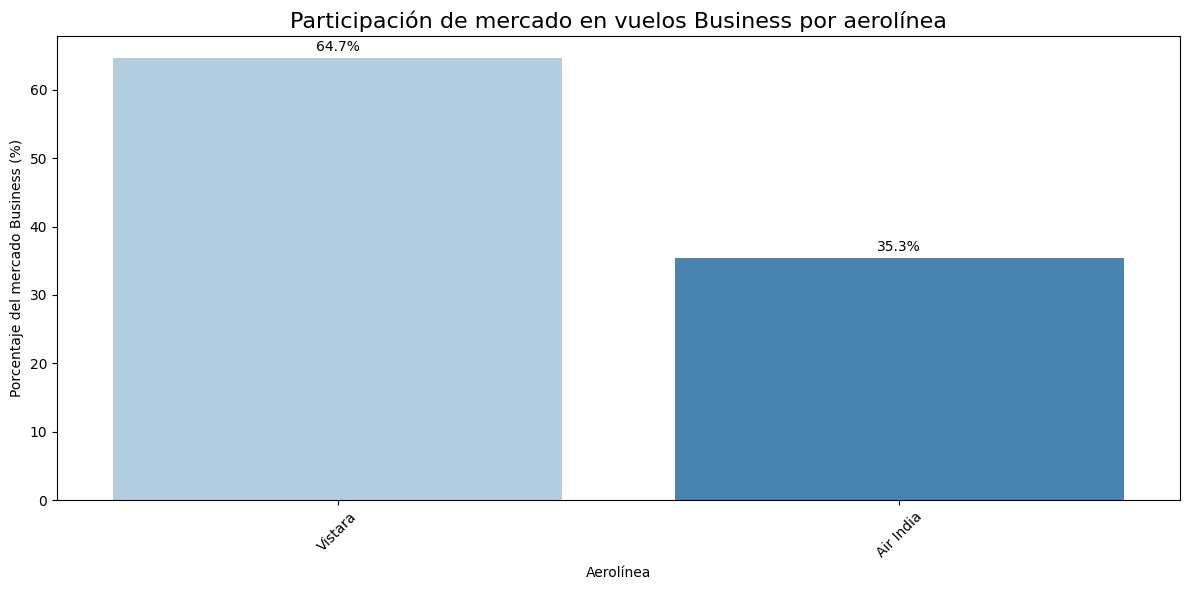

In [294]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar solo vuelos Business
business_df = train_set[train_set['class'] == 'business']

# Contar vuelos business por aerolínea
business_counts = business_df['airline'].value_counts()

# Calcular porcentaje sobre el total del mercado business
business_percent = business_counts / business_counts.sum() * 100

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=business_percent.index,
    y=business_percent.values,
    palette="Blues"
)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Participación de mercado en vuelos Business por aerolínea", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje del mercado Business (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Porcentaje por aerolinea de Economy

C:\Users\lufue\AppData\Local\Temp\ipykernel_17540\1095963594.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


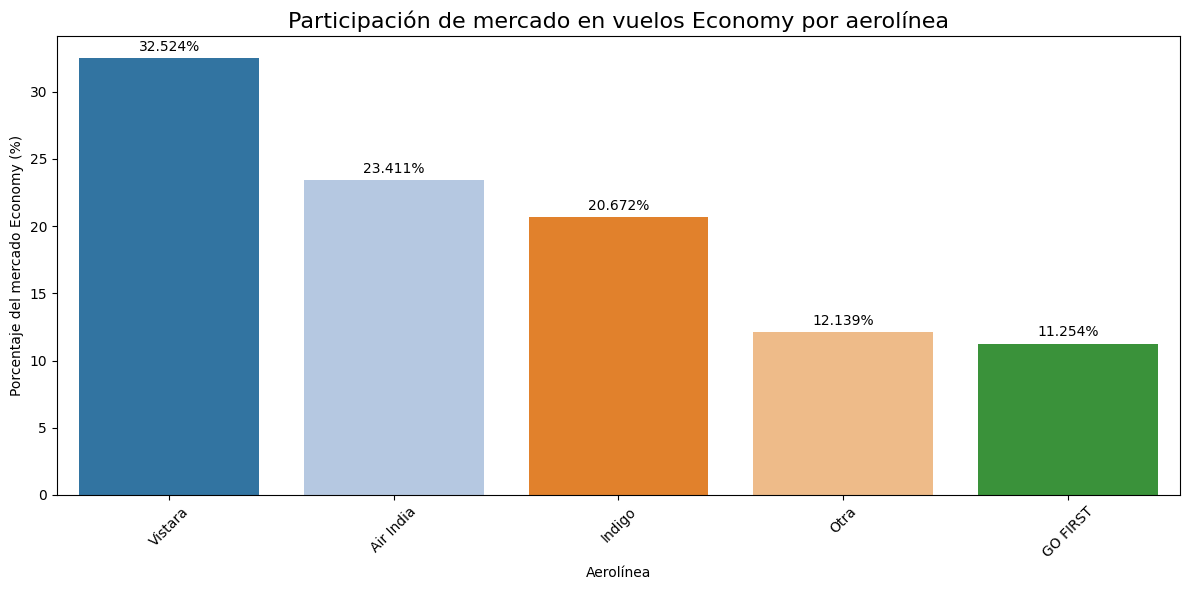

In [295]:
# Paleta igual que el pie chart
colors = sns.color_palette("tab20")

# Orden de aerolíneas según el pie chart
counts = train_set["airline"].value_counts()
airline_order = counts.index.tolist()

# Filtrar solo vuelos Economy
economy_df = train_set[train_set['class'] == 'economy']

# Contar vuelos economy por aerolínea
economy_counts = economy_df['airline'].value_counts()

# Calcular porcentaje sobre el total del mercado economy
economy_percent = economy_counts / economy_counts.sum() * 100

# Alinear colores con el orden del pie chart
economy_colors = [colors[airline_order.index(a)] for a in economy_percent.index]

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=economy_percent.index,
    y=economy_percent.values,
    palette=economy_colors
)

# Etiquetas encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f%%', padding=3)

plt.title("Participación de mercado en vuelos Economy por aerolínea", fontsize=16)
plt.xlabel("Aerolínea")
plt.ylabel("Porcentaje del mercado Economy (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Analizando todo esto 

Air India debe ser tu aerolínea
Y te explico por qué es la opción más sólida:

1. Tiene un tamaño grande pero no dominante
- No es tan gigante como Vistara
- No es tan pequeña como Indigo
- Está justo en el medio

2. Tiene mezcla de clases
- 35% del mercado Business
- 23% del mercado Economy
- Ingresos altos pero no extremos
- Esto es perfecto para un modelo de ML porque hay variabilidad real.

3. Tiene rivales claros
- Premium: Vistara
- Low‑cost: Indigo, GO FIRST, AirAsia, SpiceJet
- Tu modelo podrá aprender patrones de ambos mundos.

4. Es la aerolínea más equilibrada del dataset
- Ni demasiado premium
- Ni demasiado low‑cost
- Ni demasiado pequeña
- Ni demasiado dominante

Es la aerolínea “intermedia” ideal para un proyecto académico.

¿Por qué NO incluir StarAir y TruJet?
Tus gráficos muestran:

StarAir:
- 0.02% de los vuelos
- ingresos insignificantes
- casi sin datos
- comportamiento no representativo
- demasiado ruido para un modelo de ML

TruJet:
- 0.014% de los vuelos
- aún menos datos
- no aporta señal
- puede distorsionar el modelo

Son outliers del mercado, no competidores reales de Air India

Qué aerolíneas SÍ incluir?

Estas son las que realmente compiten en el mercado:

Vistara: 
- Rival premium
- Mucho volumen
- Precios altos
- Perfecta para estudiar

GO FIRST:
- Low‑cost
- Competidor directo en rutas económicas

AirAsia
- Low‑cost
- Patrón de precios interesante

SpiceJet
- Low‑cost
- Competidor real en rutas domésticas

In [86]:
df_ml.info()

<class 'pandas.DataFrame'>
Index: 217225 entries, 0 to 298208
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           217225 non-null  str    
 1   source_city       217225 non-null  str    
 2   destination_city  217225 non-null  str    
 3   price             217225 non-null  float64
 4   duration          217225 non-null  float64
 5   dep_time_cat      217225 non-null  str    
 6   arr_time_cat      217225 non-null  str    
 7   days_left         217225 non-null  int64  
 8   class             217225 non-null  str    
 9   stop_num          217225 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 18.2 MB


In [87]:
df_ml.describe()

,price,duration,days_left,stop_num
count,217225.000000,217225.000000,217225.000000,217225.000000
mean,20024.419883,11.077931,25.193546,0.916115
std,23304.681420,6.617793,13.488459,0.408854
min,1105.000000,0.833333,0.000000,0.000000
25%,4502.000000,6.333333,14.000000,1.000000
50%,6728.000000,10.083333,25.000000,1.000000
75%,38099.000000,14.500000,37.000000,1.000000
max,123071.000000,47.083333,48.000000,2.000000


Matriz de correlacion 

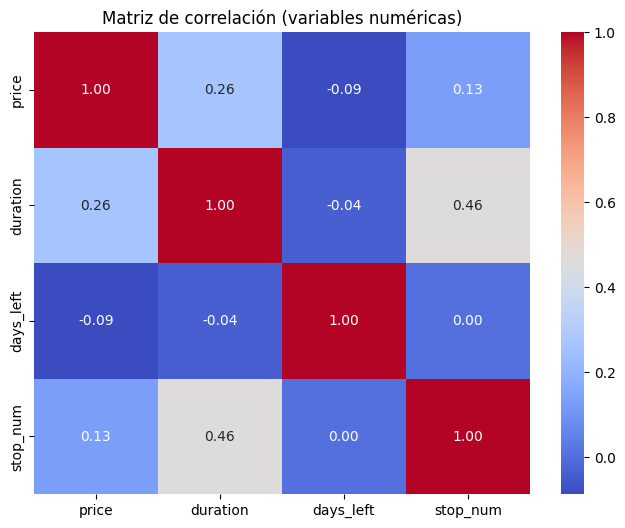

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo columnas numéricas
num_cols = ['price', 'duration', 'days_left', 'stop_num']

corr_matrix = df_ml[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación (variables numéricas)")
plt.show()


Histograma de la variable target 

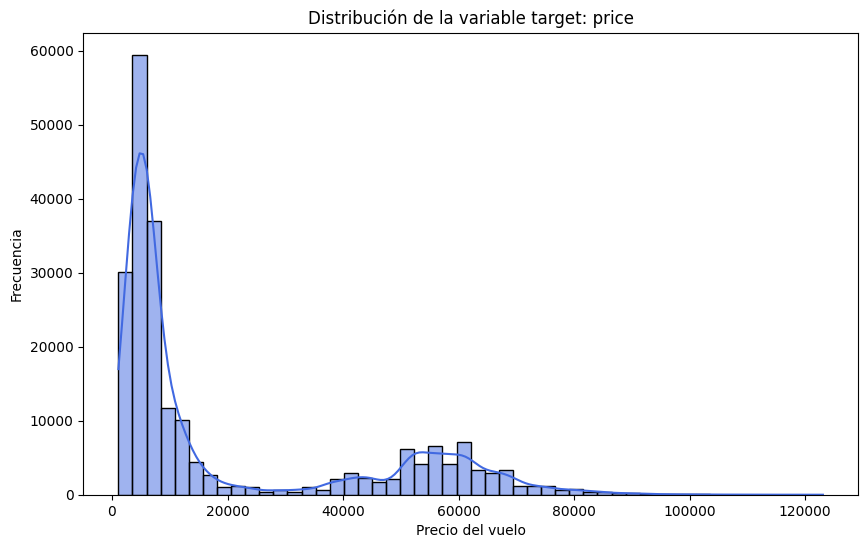

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_ml['price'], bins=50, kde=True, color='royalblue')
plt.title("Distribución de la variable target: price")
plt.xlabel("Precio del vuelo")
plt.ylabel("Frecuencia")
plt.show()


**Machine_Learning**

In [90]:
features_num = ['duration', 'days_left', 'stop_num']

features_cat = [
    'airline',
    'source_city',
    'destination_city',
    'dep_time_cat',
    'arr_time_cat',
    'class'
]



In [91]:
from sklearn.model_selection import train_test_split

X = df_ml[features_num + features_cat]
y = df_ml['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [ ]:
'''from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', StandardScaler(), features_num)
    ]
)'''


PIPELINE 1 — Modelos lineales (OneHot + StandardScaler)

In [92]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', StandardScaler(), features_num)
    ]
)


PIPELINE 2 — Modelos de árboles (OneHot + numéricas sin tocar)

In [ ]:
'''preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features_cat),
        ('num', 'passthrough', features_num)
    ]
)'''


In [93]:
from sklearn.preprocessing import OrdinalEncoder

preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), features_cat),
        ('num', 'passthrough', features_num)
    ]
)


PIPELINE 3 — CatBoost (sin preprocesamiento)

In [94]:
from catboost import CatBoostRegressor

model_cat = CatBoostRegressor(
    depth=8,
    learning_rate=0.05,
    iterations=600,
    loss_function="RMSE",
    verbose=0,
    random_state=42
)


In [95]:
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)


BLOQUE 1 — Modelos lineales

In [96]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
import numpy as np

models_linear = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

results_linear = {}

for name, reg in models_linear.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_linear[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")



📌 LinearRegression
   RMSE CV: 6704.70
   MAE  CV: 4256.78
   R²   CV: 0.9171

📌 Ridge
   RMSE CV: 6704.70
   MAE  CV: 4256.65
   R²   CV: 0.9171

📌 Lasso
   RMSE CV: 6704.72
   MAE  CV: 4254.87
   R²   CV: 0.9171


BLOQUE 2 — Modelos de árboles

In [97]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models_trees = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=400, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1
    )
}

results_trees = {}

for name, reg in models_trees.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_trees),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_trees[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")



📌 RandomForest
   RMSE CV: 3028.55
   MAE  CV: 1247.54
   R²   CV: 0.9831

📌 XGBoost
   RMSE CV: 3737.24
   MAE  CV: 2118.54
   R²   CV: 0.9742

📌 LightGBM
   RMSE CV: 3633.81
   MAE  CV: 2112.41
   R²   CV: 0.9756


BLOQUE 3 — CatBoost (sin preprocesador)

In [98]:
results_cat = {}

rmse = -cross_val_score(model_cat, X_train, y_train,
                        scoring='neg_root_mean_squared_error',
                        cv=5, n_jobs=-1).mean()

mae  = -cross_val_score(model_cat, X_train, y_train,
                        scoring=mae_scorer,
                        cv=5, n_jobs=-1).mean()

r2   =  cross_val_score(model_cat, X_train, y_train,
                        scoring=r2_scorer,
                        cv=5, n_jobs=-1).mean()

results_cat["CatBoost"] = {"RMSE": rmse, "MAE": mae, "R2": r2}

print(f"\n📌 CatBoost")
print(f"   RMSE CV: {rmse:.2f}")
print(f"   MAE  CV: {mae:.2f}")
print(f"   R²   CV: {r2:.4f}")


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "_catboost.pyx", line 2606, in _catboost.get_float_feature
  File "_catboost.pyx", line 1290, in _catboost._FloatOrNan
  File "_catboost.pyx", line 1039, in _catboost._FloatOrNanFromString
TypeError: Cannot convert 'Vistara' to float

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 6178, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 2701, in _fit
    train_params = self._prepare_train_params(
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 2581, in _prepare_train_params
    train_pool = _build_train_pool(X, y, cat_features, text_features, embedding_features, pairs, graph,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 1540, in _build_train_pool
    train_pool = Pool(X, y, cat_features=cat_features, text_features=text_features, embedding_features=embedding_features, pairs=pairs, graph=graph, weight=sample_weight, group_id=group_id,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 863, in __init__
    self._init(data, label, cat_features, text_features, embedding_features, embedding_features_data, pairs, graph, weight,
  File "c:\Users\César\OneDrive\Escritorio\DS\ML_Prediccion_Precios_Vuelos\.venv\Lib\site-packages\catboost\core.py", line 1518, in _init
    self._init_pool(data, label, cat_features, text_features, embedding_features, embedding_features_data, pairs, graph, weight,
  File "_catboost.pyx", line 4695, in _catboost._PoolBase._init_pool
  File "_catboost.pyx", line 4753, in _catboost._PoolBase._init_pool
  File "_catboost.pyx", line 4541, in _catboost._PoolBase._init_features_order_layout_pool
  File "_catboost.pyx", line 3189, in _catboost._set_features_order_data_pd_data_frame
  File "_catboost.pyx", line 2673, in _catboost.create_num_factor_data
  File "_catboost.pyx", line 2635, in _catboost._set_features_order_data_frame_generic_num_column
  File "_catboost.pyx", line 2608, in _catboost.get_float_feature
_catboost.CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=3]="Vistara": Cannot convert 'Vistara' to float


BLOQUE 1 — Modelos lineales

In [91]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

models_linear = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso()
}

results_linear = {}

for name, reg in models_linear.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_linear[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")



📌 LinearRegression
   RMSE CV: 6704.70
   MAE  CV: 4256.78
   R²   CV: 0.9171

📌 Ridge
   RMSE CV: 6704.70
   MAE  CV: 4256.65
   R²   CV: 0.9171

📌 Lasso
   RMSE CV: 6704.72
   MAE  CV: 4254.87
   R²   CV: 0.9171


BLOQUE 2 — Modelos de árboles

In [92]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models_trees = {
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="reg:squarederror", random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=400, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42
    )
}

results_trees = {}

for name, reg in models_trees.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor_trees),
        ('regressor', reg)
    ])
    
    rmse = -cross_val_score(pipe, X_train, y_train,
                            scoring='neg_root_mean_squared_error',
                            cv=5, n_jobs=-1).mean()
    
    mae  = -cross_val_score(pipe, X_train, y_train,
                            scoring=mae_scorer,
                            cv=5, n_jobs=-1).mean()
    
    r2   =  cross_val_score(pipe, X_train, y_train,
                            scoring=r2_scorer,
                            cv=5, n_jobs=-1).mean()

    results_trees[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"\n📌 {name}")
    print(f"   RMSE CV: {rmse:.2f}")
    print(f"   MAE  CV: {mae:.2f}")
    print(f"   R²   CV: {r2:.4f}")


KeyboardInterrupt: 

BLOQUE 3 — CatBoost (sin preprocesador)

In [ ]:
results_cat = {}

rmse = -cross_val_score(model_cat, X_train, y_train,
                        scoring='neg_root_mean_squared_error',
                        cv=5, n_jobs=-1).mean()

mae  = -cross_val_score(model_cat, X_train, y_train,
                        scoring=mae_scorer,
                        cv=5, n_jobs=-1).mean()

r2   =  cross_val_score(model_cat, X_train, y_train,
                        scoring=r2_scorer,
                        cv=5, n_jobs=-1).mean()

results_cat["CatBoost"] = {"RMSE": rmse, "MAE": mae, "R2": r2}

print(f"\n📌 CatBoost")
print(f"   RMSE CV: {rmse:.2f}")
print(f"   MAE  CV: {mae:.2f}")
print(f"   R²   CV: {r2:.4f}")


In [189]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "SVR": SVR(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),

    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        depth=8,
        learning_rate=0.05,
        iterations=600,
        loss_function="RMSE",
        verbose=0,
        random_state=42
    )
}


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
import numpy as np

mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score)

results = {}

for name, reg in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', reg)
    ])
    
    # RMSE
    rmse_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring='neg_root_mean_squared_error',
        cv=5
    )
    
    # MAE
    mae_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring=mae_scorer,
        cv=5
    )
    
    # R²
    r2_scores = cross_val_score(
        pipe, X_train, y_train,
        scoring=r2_scorer,
        cv=5
    )
    
    results[name] = {
        "RMSE_CV": -rmse_scores.mean(),
        "MAE_CV": -mae_scores.mean(),
        "R2_CV": r2_scores.mean()
    }
    
    print(f"\n📌 Modelo: {name}")
    print(f"   RMSE CV: {-rmse_scores.mean():.2f}")
    print(f"   MAE  CV: {-mae_scores.mean():.2f}")
    print(f"   R²   CV: {r2_scores.mean():.4f}")



📌 Modelo: LinearRegression
   RMSE CV: 6704.70
   MAE  CV: 4256.78
   R²   CV: 0.9171

📌 Modelo: Ridge
   RMSE CV: 6704.70
   MAE  CV: 4256.65
   R²   CV: 0.9171

📌 Modelo: Lasso
   RMSE CV: 6704.72
   MAE  CV: 4254.87
   R²   CV: 0.9171


In [23]:


dup_economy = df_economy[df_economy.duplicated(subset=cols, keep=False)]
dup_business = df_business[df_business.duplicated(subset=cols, keep=False)]

len(dup_economy), len(dup_business)


(70, 0)

In [24]:
df_concat = pd.concat([df_economy, df_business], ignore_index=True)

df_concat_clean = df_concat.drop_duplicates(subset=cols)

df_concat.shape[0] - df_concat_clean.shape[0]


35